In [1]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, te, intercept 
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.path import Path
from shapely.geometry import Polygon, MultiPolygon
from scipy.stats import norm, t as student_t
from matplotlib import colors
import torch.nn.functional as Fnn

import math
import torch
import torch.nn as nn
import torch.optim as optim
import gpytorch
from torch.distributions import Normal
from dataclasses import dataclass
from kmeans_pytorch import kmeans

torch.set_default_dtype(torch.float64)




Base model fitting

In [2]:
# Set random seeds for reproducibility.
torch.manual_seed(1)
np.random.seed(1)

In [3]:
# data preparation
df = pd.read_csv("weather_data.csv",index_col="date")
df.index = pd.to_datetime(df.index)

df['t'] = (df.index-df.index[0])/pd.Timedelta(days=1)
df["t"] = df["t"]/df["t"].max() # time 0-1


# Retain the selected one-year window and rescale its time coordinate.
df = df[(df['t']>1/6) & (df['t']<2/6)].copy()
df["t"] = (df["t"]-df["t"].min())/(df["t"].max()-df["t"].min()) # time 0-1



X = df[['t','longitude','latitude']].values
y = df['temperature'].values



# standardize X 
x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
X = (X - x_mean) / x_std

# map X to [-1, 1]
X = (2 / (1+np.exp(-X))) - 1

# standardize y
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std



In [4]:
x_all, y_all = X, y
rand_indices = torch.randperm(x_all.shape[0], generator=torch.Generator())
x_train, y_train = x_all[rand_indices[:-x_all.shape[0]//10]], y_all[rand_indices[:-x_all.shape[0]//10]]  # 90% train, 10% test
x_test, y_test = x_all[rand_indices[-x_all.shape[0]//10:]], y_all[rand_indices[-x_all.shape[0]//10:]]

(array([2445., 5091., 5110., 4380., 3285., 4015., 4015., 4959., 2920.,
        2906., 4380., 2555., 4380., 1825., 4745., 2555., 3650., 3285.,
        1427., 4380., 3285., 4719., 4380., 3285., 5110., 5110., 4380.,
        2920., 3650., 3285., 2920., 3428., 4003., 2190., 3285., 1460.,
        2920., 3650., 1825.,  611., 3137., 2555., 1825., 2920., 4015.,
        2918., 4551., 3832., 2555.,  730.]),
 array([-0.70779728, -0.6774932 , -0.64718912, -0.61688504, -0.58658095,
        -0.55627687, -0.52597279, -0.49566871, -0.46536463, -0.43506055,
        -0.40475647, -0.37445239, -0.34414831, -0.31384423, -0.28354015,
        -0.25323607, -0.22293198, -0.1926279 , -0.16232382, -0.13201974,
        -0.10171566, -0.07141158, -0.0411075 , -0.01080342,  0.01950066,
         0.04980474,  0.08010882,  0.1104129 ,  0.14071699,  0.17102107,
         0.20132515,  0.23162923,  0.26193331,  0.29223739,  0.32254147,
         0.35284555,  0.38314963,  0.41345371,  0.44375779,  0.47406187,
         0.50436

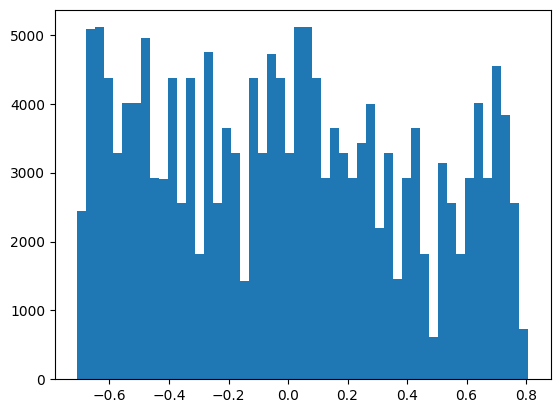

In [5]:
plt.hist(x_all[:,2], bins=50)

In [6]:
# fit the GAM model
gam = LinearGAM(intercept + s(0,n_splines=5)+te(1,2,n_splines=[5,5]))

gam.fit(x_train,y_train)

print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.0087
Link Function:                     IdentityLink Log Likelihood:                               -214078.3519
Number of Samples:                       150985 AIC:                                           428196.7212
                                                AICc:                                          428196.7268
                                                GCV:                                                 0.285
                                                Scale:                                               0.285
                                                Pseudo R-Squared:                                   0.7155
Feature Function                  Lam

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/3768786032.py:9: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [7]:
# parameters of the base model for each observation
df["mu"] = gam.predict(X) 
df["sigma"] = np.std(y-df["mu"])#gam.statistics_["scale"] # a single scale estimate for all data points
df["z"] = norm(loc=df["mu"],scale=df["sigma"]).cdf(y) # base model cdf value z = G(y|x)


# Base model constants: g_tilde (Normal GAM) and g (moment-matched t-distribution)
# g_tilde: Normal base model from GAM (used for visualization later)
SIGMA_NORMAL = np.std(y-df["mu"])#gam.statistics_["scale"] # Same scale as GAM

ORIGINAL_SIGMA_NORMAL = SIGMA_NORMAL  # Store the original GAM-based scale for reference

SIGMA_NORMAL = SIGMA_NORMAL * 3.0  # Adjust this factor to control how closely g_tilde matches the GAM fit (1.0 means exact match)


# g: t-distributed base model with moment matching (used in GPDR optimization)
# Uses the same location (GAM prediction) and scale as g_tilde, but with heavier tails (df=3)
SCALE_T = SIGMA_NORMAL  # Moment-matched scale
DF = 3.0  # Degrees of freedom for t-distribution

print(f"Base model g_tilde (Normal GAM): scale = {SIGMA_NORMAL:.4f}")
print(f"Base model g (t-dist): scale = {SCALE_T:.4f}, df = {DF}")

Base model g_tilde (Normal GAM): scale = 1.5995
Base model g (t-dist): scale = 1.5995, df = 3.0


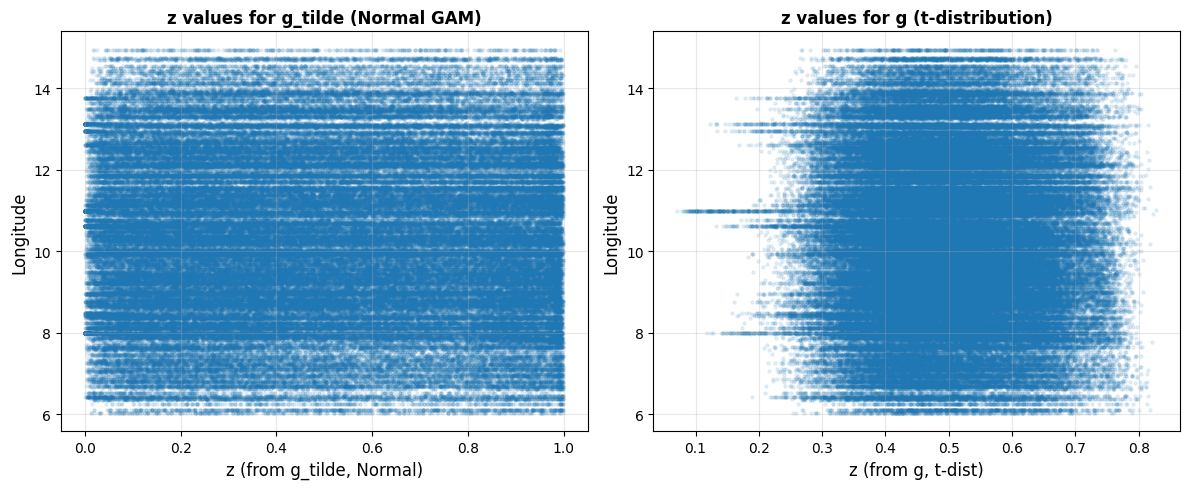

In [8]:
# Compute z values for both base models
# z for g_tilde (Normal): already computed as df["z"]
# z for g (t-distribution): compute using t-distribution CDF
df["z_t"] = student_t.cdf(y, DF, loc=df["mu"], scale=SCALE_T)

# Create side-by-side comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot for g_tilde (Normal base)
ax1.scatter(df.z, df.longitude, alpha=0.1, s=5)
ax1.set_xlabel('z (from g_tilde, Normal)', fontsize=12)
ax1.set_ylabel('Longitude', fontsize=12)
ax1.set_title('z values for g_tilde (Normal GAM)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot for g (t-distribution base)
ax2.scatter(df.z_t, df.longitude, alpha=0.1, s=5)
ax2.set_xlabel('z (from g, t-dist)', fontsize=12)
ax2.set_ylabel('Longitude', fontsize=12)
ax2.set_title('z values for g (t-distribution)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


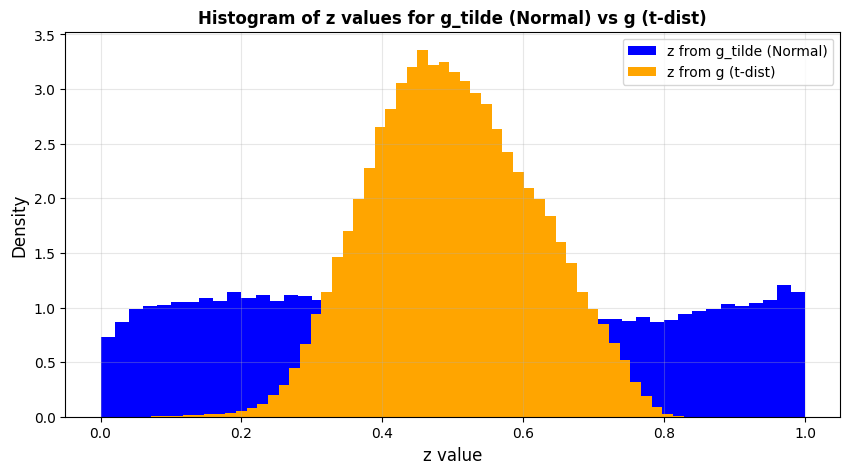

In [9]:
# z values histogram
plt.figure(figsize=(10, 5))
plt.hist(df.z, bins=50, alpha=1, label='z from g_tilde (Normal)', color='blue', density=True)
plt.hist(df.z_t, bins=50, alpha=1, label='z from g (t-dist)', color='orange', density=True)
plt.xlabel('z value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Histogram of z values for g_tilde (Normal) vs g (t-dist)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print(gam.distribution._known_scale) # In this base model, we do not announce a scale for response varianble distirbution
# Therefore, by classical GAM theory, the scale parameter is estimated

print(gam.statistics_["scale"])

False
0.28498460079055776


In [11]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES" # to make de.shp file work in geopandas


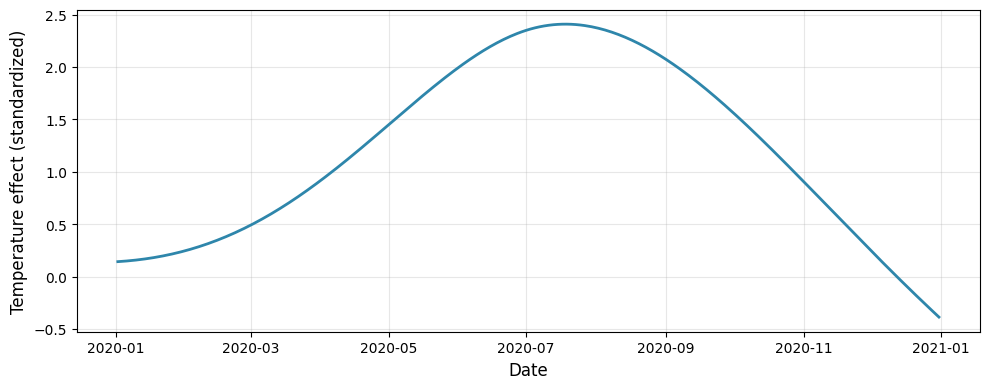

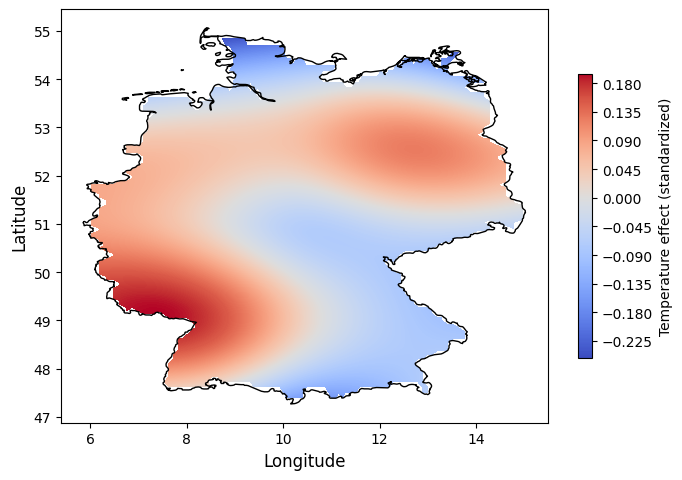

In [12]:
### plots of the effects ###

def points_in_polygon_path(xy, poly: Polygon):
    # exterior
    ext_path = Path(np.asarray(poly.exterior.coords))
    inside_ext = ext_path.contains_points(xy)
    # holes (interiors)
    if len(poly.interiors):
        inside_holes = np.zeros(xy.shape[0], dtype=bool)
        for ring in poly.interiors:
            hole_path = Path(np.asarray(ring.coords))
            inside_holes |= hole_path.contains_points(xy)
        return inside_ext & ~inside_holes
    else:
        return inside_ext

# Seasonal effect (temporal effect)
f_t = gam.partial_dependence(term=1, X=X)   # how the model's prediction changes when a date changes, while averaging over all other features, i.e. Seasonal effect
plt.figure(figsize=(10, 4))
plt.plot(df.index, f_t, color='#2E86AB', linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature effect (standardized)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('base_model_temporal_effect.pdf', dpi=300, bbox_inches='tight')
plt.show()

XX = gam.generate_X_grid(term=2, meshgrid=True)
Z = gam.partial_dependence(term=2, X=XX, meshgrid=True) # te(lon,lat) effect

Z = Z-Z.mean()



# Undo the nonlinear covariate transform and standardization for plotting.
XX_original = [
    -np.log(2/(XX[0]+1)-1) * x_std[1] + x_mean[1],  # longitude (index 1 in X)
    -np.log(2/(XX[1]+1)-1) * x_std[2] + x_mean[2]   # latitude (index 2 in X)
]



gdf = gpd.read_file("de.shp")
gdf = gdf.explode(index_parts=False)

x_flat = XX_original[0].ravel()
y_flat = XX_original[1].ravel()
xy = np.column_stack([x_flat, y_flat]) # locations of each grid points

outside = np.ones(xy.shape[0], dtype=bool)

for geom in gdf.geometry:
    if isinstance(geom, Polygon):
        inside_poly = points_in_polygon_path(xy, geom)
        outside &= ~inside_poly  
    elif isinstance(geom, MultiPolygon):
        inside_any = np.zeros(xy.shape[0], dtype=bool)
        for part in geom.geoms:
            inside_any |= points_in_polygon_path(xy, part)
        outside &= ~inside_any
    else:
        continue

mask = outside.reshape(XX_original[0].shape)
Z_masked = np.ma.array(Z, mask=mask)

fig, ax = plt.subplots(figsize=(7, 6))
vmin = np.nanmin(Z_masked)
vmax = np.nanmax(Z_masked)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cm = ax.contourf(XX_original[0], XX_original[1], Z_masked, levels=300, cmap='coolwarm',norm=norm)
gdf.boundary.plot(ax=ax, color='k', linewidth=1.0)
fig.colorbar(cm, ax=ax, shrink=0.5, label='Temperature effect (standardized)')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('base_model_spatial_effect.pdf', dpi=300, bbox_inches='tight')
plt.show()


GPDR

In [13]:
# Minimal PyTorch + GPyTorch implementation of Logistic GP density regression
# with a mixture variational posterior over f_z at inducing points
# (learns mixture weights ω, means μ_k, and diagonal covariances Σ_k = diag(v_k)).

# All the x, y's are torch tensors

dim_x = 3

def normal_pdf(y, mu, sigma):
    # Normal reference density.
    return (1.0 / (math.sqrt(2.0 * math.pi) * sigma)) * torch.exp(-0.5 * ((y - mu) / sigma)**2)

def t_pdf(y, mu, sigma, df=DF):
    """
    Student's t-distribution PDF using scipy.
    Returns PDF of t(loc=mu, scale=sigma, df=df) at y.
    """
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy() if torch.is_tensor(mu) else mu
    sigma_np = sigma if isinstance(sigma, float) else sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy student_t
    pdf_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    return torch.tensor(pdf_np, dtype=y.dtype, device=y.device)

def base_g_terms(y, x, sigma=SCALE_T, df=DF):
    """
    Base model using Student's t-distribution: t(loc=GAM(x), scale=sigma, df=df).
    Returns g(y|x), g'(y|x), g''(y|x).
    Uses scipy.stats.student_t.
    """
    # Convert to numpy for GAM prediction, then back to tensor
    mu = torch.tensor(gam.predict(x.cpu().numpy()), device=x.device, dtype=x.dtype)
    
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy()
    sigma_np = sigma if isinstance(sigma, float) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy.stats.student_t for PDF
    g_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    g = torch.tensor(g_np, dtype=y.dtype, device=y.device)
    
    # Compute derivatives using manual formulas
    z = (y - mu) / sigma
    gy = -(df + 1) * z * g / (sigma * (df + z**2))
    gyy = g * (-(df + 1) / (sigma**2 * (df + z**2)) + (df + 1) * z**2 * (df + 3) / (sigma**2 * (df + z**2)**2))
    
    return g, gy, gyy

def to_z_from_y(y, x, sigma=SCALE_T, df=DF):
    """
    Transform y to z using CDF of Student's t-distribution.
    z = CDF_t((y - mu) / sigma)
    Uses t(loc=GAM(x), scale=sigma, df=df).
    """
    # Convert to numpy for GAM prediction
    mu = torch.tensor(gam.predict(x.cpu().numpy()), device=x.device, dtype=x.dtype)
    
    # Use scipy.stats.t with explicit loc and scale
    mu_np = mu.cpu().numpy()
    sigma_np = sigma if isinstance(sigma, float) else sigma
    y_np = y.cpu().numpy()
    z_np = student_t.cdf(y_np, df, loc=mu_np, scale=sigma_np)
    z = torch.tensor(z_np, dtype=y.dtype, device=y.device)
    
    return z

# 2) Kernel (RBF with ARD) and derivative blocks

@dataclass
class KernelParams:
    log_sigma2: float = math.log(0.1806**2)
    log_lz2: float    = math.log(0.2360**2)
    
    def get_lx2(self, device, dtype):
        """Get lengthscale tensor on the correct device/dtype"""
        log_lx2 = torch.tensor([math.log(0.4901**2) for s in range(dim_x)], device=device, dtype=dtype)
        return torch.exp(log_lx2)

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    """
    Just wraps GPyTorch's RBFKernel+ScaleKernel to compute the base k((x,z),(x',z')).
    We still implement the derivative covariances in closed-form (simple and fast).
    """
    def __init__(self, kp: KernelParams, device=torch.device("cpu"), dtype=torch.float32):
        super().__init__()
        self.register_buffer("lx2", kp.get_lx2(device, dtype)) # Squared x lengthscales.
        self.register_buffer("lz2", torch.tensor(kp.lz2, device=device, dtype=dtype)) # Squared z lengthscale.
        self.register_buffer("sigma2", torch.tensor(kp.sigma2, device=device, dtype=dtype))
        # GPyTorch kernel representation; derivative blocks below use explicit formulas.
        self.base = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=1+dim_x, has_lengthscale=True)
        )
        # Initialize the GPyTorch representation with the same kernel parameters.
        with torch.no_grad():
            # lengthscales per-dimension: [sqrt(lx2), sqrt(lz2)]
            lx2_cpu = kp.get_lx2(torch.device("cpu"), torch.float64)  # GPyTorch needs CPU tensors
            lz2_cpu = torch.tensor(kp.lz2, dtype=torch.float64)
            self.base.base_kernel.lengthscale = torch.sqrt(torch.cat([lx2_cpu.reshape(1,-1), lz2_cpu.reshape(1,-1)],dim=1)[None, None, :])
            self.base.outputscale = torch.tensor(kp.sigma2, dtype=torch.float64) # initialized value of σ^2 for covariance function



    def delta_01(self, V, U):
        # Cov(f, f'_z) = ∂/∂z' k
        # Using closed-form for RBF:
        # k = σ^2 exp(-(dx^2/lx2 + dz^2/lz2))
        # ∂k/∂z' = k * (2 (z - z') / lz2)
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T
        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,dim_x)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,dim_x)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,dim_x)
        dx2 = dist2.sum(-1)  # shape (n,n)

        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (2.0 * dz / self.lz2)


    def delta_11(self, V, U):
        # Cov(f'_z, f'_z) = ∂^2/(∂z ∂z') k
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T
        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,dim_x)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,dim_x)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,dim_x)
        dx2 = dist2.sum(-1)  # shape (n,n)

        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * (dz2))

        # Add small nugget to diagonal for numerical stability
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result += 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
            
        return result

    def delta_21(self, V, U):
        # Cov(f''_z, f'_z) = ∂^3/(∂z^2 ∂z') k
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T

        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,2)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,2)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,2)
        dx2 = dist2.sum(-1)  # shape (n,n)

        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))
    

def chol_inv(K):
    """Improved Cholesky inversion with MPS compatibility"""
    try:
        L = torch.linalg.cholesky(K)
        I = torch.eye(K.size(-1), dtype=K.dtype, device=K.device)
        
        # MPS doesn't support cholesky_solve, use alternative approach
        if K.device.type == "mps":
            # Solve L @ L.T @ X = I using forward and backward substitution
            # First solve L @ Y = I for Y
            Y = torch.linalg.solve_triangular(L, I, upper=False)
            # Then solve L.T @ X = Y for X
            Kinv = torch.linalg.solve_triangular(L.T, Y, upper=True)
        else:
            # Use cholesky_solve for CUDA/CPU
            Kinv = torch.cholesky_solve(I, L)
        return Kinv, L
    except Exception as e:
        # Fallback to SVD-based pseudoinverse if Cholesky fails
        print(f"Cholesky failed: {e}, using SVD fallback")
        U, S, Vt = torch.linalg.svd(K)
        # Filter out small singular values
        threshold = 1e-10 * S[0]  # relative to largest singular value
        S_inv = torch.where(S > threshold, 1.0 / S, 0.0)
        Kinv = (Vt.T * S_inv.unsqueeze(0)) @ Vt
        return Kinv, None


# 3) Variational mixture over f_z (diagonal Σ_k)
class LogisticGPMixtureDiag(nn.Module):
    """
    Variational family: q(f̃_z) = Σ_k ω_k N(μ_k, diag(v_k)), v_k = exp(2 s_k).
    Minimizes:  KL(q || GP prior on f'_z at inducing) + β * Hyvärinen score.
    The KL term uses the one-Gaussian special case of Goldberger's approximation,
    so the mixture weights enter through an extra Σ_k ω_k log ω_k term.
    For the f_zz imputation we use a Gumbel-softmax relaxation so the sampled
    latent inducing vector remains stochastic while the term stays differentiable
    with respect to the mixture weights.
    """
    def __init__(self, x, y, C=2, m_induce=121, beta=1.0, kp: KernelParams = KernelParams(), gumbel_tau=0.5):
        super().__init__()
        g = torch.Generator()

        self.x = x.detach()
        self.y = y.detach()
        self.n = x.numel()
        self.C = C
        self.beta = beta
        self.gumbel_tau = gumbel_tau
        self.kern = RBF_SE_ARD(kp, device=self.x.device, dtype=self.x.dtype)

        # Transform to z and build training inputs V = (x, z)
        z = to_z_from_y(self.y, self.x)
        z = torch.clamp(z, 1e-5, 1-1e-5)

        self.V = torch.cat([self.x, z.reshape(-1,1)], dim=1)  # (n, dim_x + 1)




        # Using Kmeans clustering
        n_per_dim = int(round(m_induce ** (1/(dim_x+1))))  # root for (dim_x+1)-D grid
        totalnum_xpoints = n_per_dim ** dim_x
        
        # Perform final clustering with optimal k
        optimal_k = totalnum_xpoints
        cluster_ids_x, cluster_centers = kmeans(
            X=self.x, num_clusters=optimal_k, distance='euclidean', device=self.x.device
        )
        
        points_allcluster = torch.zeros((0, dim_x), device=self.x.device, dtype=self.x.dtype)
        for u in range(optimal_k):
            cluster_center = torch.tensor(cluster_centers[u], device=self.x.device, dtype=self.x.dtype)
            points_allcluster = torch.cat([points_allcluster, cluster_center.unsqueeze(0)], dim=0)
        
        x_grid = points_allcluster[1:,:] # Retain the notebook selection of cluster centers after the first row.
        z_grid = torch.linspace(1e-5, 1-1e-5, n_per_dim, device=self.x.device, dtype=self.x.dtype)


        # Combine selected covariate centers with the PIT grid.

        x_grid_expand = x_grid[:, None, :].expand(x_grid.size(0), n_per_dim, dim_x)   # (m,n,d)
        z_grid_expand = z_grid[None, :, None] .expand(x_grid.size(0), n_per_dim, 1)   # (m,n,1)

        out = torch.cat([x_grid_expand, z_grid_expand], dim=2).reshape(x_grid.size(0)*n_per_dim, dim_x+1)

        self.Vu = out  # (x_grid.size(0), dim_x + 1)

        self.m = self.Vu.size(0)

        # Base model terms
        self.g, self.gy, self.gyy = base_g_terms(self.y, self.x)

        # Kernel blocks
        self.K11uu = self.kern.delta_11(self.Vu, self.Vu)        # (m, m)
        self.K11uu_inv, self.K11uu_chol = chol_inv(self.K11uu) 
        self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv   # (n, m)

        self.A2 = self.A**2
        self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)  # (m,)

        # Variational parameters
        self.logits = nn.Parameter(torch.randn(C, device=self.x.device, dtype=self.x.dtype))                       # mixture weights (softmax)
        self.mus    = nn.Parameter(torch.randn(C, self.m, device=self.x.device, dtype=self.x.dtype))               # means
        init_log_std = math.log(0.35)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std, device=self.x.device, dtype=self.x.dtype))  # log std per inducing point per mixture component

        # Warm-start μ (single-component quadratic surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)              # (n,)
        W = (self.g ** 2)                                     # (n,)
        AtW = self.A.T * (W / self.n)                         # (m, n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A) # (m, m)
        b = self.beta * (self.A.T @ (lin / self.n))           # (m,)
        
        # Solve the quadratic warm-start system.
        mu_ls = -torch.linalg.solve(H, b)
        

        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / self.C + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        """
        Compute the scalar objective and autograd will populate grads:
        F = KL(q || GP prior) + β * EH
        """
        logits = self.logits
        w = torch.softmax(logits, dim=0)                           # (C,)

        aMu = (self.A @ self.mus.T).T                              # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        Ez = self.A @ mu_bar                                       # (n,)

        # Gumbel-softmax relaxation of the mixture draw for f_zz imputation.
        gumbel_u = torch.rand_like(w).clamp_(1e-12, 1.0 - 1e-12)
        gumbel_noise = -torch.log(-torch.log(gumbel_u))
        pi_soft = torch.softmax((torch.log(w + 1e-12) + gumbel_noise) / self.gumbel_tau, dim=0)
        eps_fzz = torch.randn_like(self.mus)
        u_samples = self.mus + torch.exp(self.s_params) * eps_fzz
        u_soft = torch.sum(pi_soft[:, None] * u_samples, dim=0)
        Efzz = self.B @ u_soft                                     # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g

        const     = (gyy / g) - 0.5 * (c**2)     # constant part
        lin_coeff = 2.0 * gy                      # linear-in-E[f_z]


        # ---- Var(f_z) for each component: diag(A diag(v_k) A^T) ----
        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        row_var = (self.A2 @ v_list.T).T                           # (C, n)  each row k: A^2 v_k
        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)   # (n,)
        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # ---- KL(q || GP prior) ----
        # KL per component vs N(0, K11uu)
        Kinv = self.K11uu_inv
        
        # More stable log determinant computation
        if self.K11uu_chol is not None:
            logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        else:
            sign, logdetK = torch.slogdet(self.K11uu)

            
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]                      # (m,)
            v_k  = v_list[k]                        # (m,)
            quad = mu_k @ (Kinv @ mu_k)
            tr   = torch.dot(diag_Kinv, v_k)       # scalar
            logdetSigma = 2.0 * torch.sum(self.s_params[k])
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))

        KL_k = torch.stack(KL_k)        # (C,)
        KL = torch.sum(w * KL_k) + torch.sum(w * torch.log(w + 1e-12))
        
        normalized_EH = self.beta * self.n * EH
        F = KL + normalized_EH


        return F, {"KL": KL.detach(), "normalized EH": normalized_EH.detach(), "w": w.detach()}

    # Prediction: mean-only (uses mixture-mean of μ_k), same normalization as NumPy version
    @torch.no_grad()
    def predict_density(self, x_star: float, y_min, y_max, M=1000):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype, device=self.x.device)
        z_grid = to_z_from_y(y_grid, torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1))
        z_grid = torch.clamp(z_grid, 1e-6, 1-1e-6)

        Vq = torch.cat([torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(z_grid.size(0), 1), z_grid.reshape(-1, 1)], dim=1) # (M, dim_x+1): append the PIT coordinate to each covariate row.
        # Use the same kernel matrices as during training for consistency
        K01 = self.kern.delta_01(Vq, self.Vu)
        
        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha                                       # (M,)
        
        g_vals, _, _ = base_g_terms(y_grid, torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1))
        
        # Also compute g_tilde (Normal GAM base model) for comparison using ORIGINAL_SIGMA_NORMAL (unscaled)
        mu_gam = torch.tensor(gam.predict(torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1).cpu().numpy()), device=self.x.device, dtype=self.x.dtype)
        g_tilde_vals = (1.0 / (math.sqrt(2.0 * math.pi) * ORIGINAL_SIGMA_NORMAL)) * torch.exp(-0.5 * ((y_grid - mu_gam) / ORIGINAL_SIGMA_NORMAL)**2)

        # Normalize by trapezoidal integration in PIT space.
        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        
        # Calculate dz BEFORE using it in trapezoid weights
        dz = z_sorted[1:] - z_sorted[:-1]
        
        # Standard trapezoid weights
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0
        
        # Exponentiate the sorted correction for normalization.
        exp_f = torch.exp(f_sorted)
        denom = torch.sum(exp_f * wts) + 1e-12
        h_hat = g_vals * torch.exp(f_vals) / denom

        return y_grid.cpu().numpy(), g_vals.cpu().numpy(), g_tilde_vals.cpu().numpy(), h_hat.cpu().numpy(), exp_f.cpu().numpy(), z_grid.cpu().numpy()


In [14]:
# Train with Adam and iterate averaging.

number_of_steps = 5000
step_verbose = 500
if __name__ == "__main__":
        # Auto-select device: prefer MPS (Apple) -> CUDA -> CPU
    device = (torch.device("mps") if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
              else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    print("Using device:", device)
    # Use float32 when on GPU/MPS for speed and support
    if device.type != "cpu":
        torch.set_default_dtype(torch.float32)

    x_train, y_train = torch.tensor(x_train, device=device, dtype=torch.float32), torch.tensor(y_train, device=device, dtype=torch.float32)
    x_test, y_test = torch.tensor(x_test, device=device, dtype=torch.float32), torch.tensor(y_test, device=device, dtype=torch.float32)
    
    # Convert to appropriate dtype based on device
    if device.type != "cpu":
        x_test = x_test.to(device, dtype=torch.float32)
        y_test = y_test.to(device, dtype=torch.float32)
        x_train = x_train.to(device, dtype=torch.float32)
        y_train = y_train.to(device, dtype=torch.float32)
    else:
        x_test = x_test.to(device)
        y_test = y_test.to(device)
        x_train = x_train.to(device)
        y_train = y_train.to(device)

    # Suppress kmeans clustering output during model initialization
    import io
    import sys
    import contextlib
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model = LogisticGPMixtureDiag(x_train, y_train, C=2, m_induce=1000, beta=29.6).to(device)

    # Adam optimizer (include logits so mixture weights remain trainable)
    optimizer = optim.Adam(model.parameters(), lr=0.5)
    trace = {"F": [], "w": [], "mu_norm": [], "s_mean": []}
    
    # Iterate averaging setup
    averaging_window = 500  # Average over last 500 steps
    start_averaging = number_of_steps - averaging_window
    averaged_params = None
    num_averaged = 0
    
    # Simple loop instead of closure
    for step in range(number_of_steps):
        optimizer.zero_grad()
        F, info = model.forward_objective()
        F.backward()
        optimizer.step()
        
        # --- Iterate averaging: accumulate parameters during last 500 steps ---
        if step >= start_averaging:
            with torch.no_grad():
                if averaged_params is None:
                    # Initialize storage for averaged parameters
                    averaged_params = {name: torch.zeros_like(param.data) for name, param in model.named_parameters()}
                
                # Accumulate current parameters
                for name, param in model.named_parameters():
                    averaged_params[name] += param.data
                num_averaged += 1
        
        # --- log parameter traces ---
        with torch.no_grad():
            w = torch.softmax(model.logits, dim=0).detach().cpu()
            mu_norm = torch.linalg.norm(model.mus, dim=1).detach().cpu()
            s_mean = torch.mean(model.s_params, dim=1).detach().cpu()
            trace["F"].append(float(F.detach()))
            trace["w"].append(w.numpy().copy())
            trace["mu_norm"].append(mu_norm.numpy().copy())
            trace["s_mean"].append(s_mean.numpy().copy())
        
        # Print progress
        if step % step_verbose == 0:
            print(f"Step {step:6d}/{number_of_steps} | F = {float(F.detach()):.4f} | KL = {info['KL']:.4f} | normalized EH = {info['normalized EH']:.4f}")
    
    # Apply averaged parameters to model
    if averaged_params is not None and num_averaged > 0:
        with torch.no_grad():
            for name, param in model.named_parameters():
                param.data.copy_(averaged_params[name] / num_averaged)
        averaging_status = f"✓ Applied iterate averaging over last {num_averaged} steps"
    else:
        averaging_status = "✗ No averaging applied"
    
    print(f"\nOptimization completed!")
    print(f"Final: F = {float(F.detach()):.4f} | KL = {info['KL']:.4f} | normalized EH = {info['normalized EH']:.4f}")
    print(f"{averaging_status}")


Using device: mps
Step      0/5000 | F = -5524169.5000 | KL = 101509.4766 | normalized EH = -5625679.0000
Step    500/5000 | F = -38255400.0000 | KL = 899021.8750 | normalized EH = -39154420.0000
Step   1000/5000 | F = -38854204.0000 | KL = 1040694.1250 | normalized EH = -39894900.0000
Step   1500/5000 | F = -39168576.0000 | KL = 1141652.2500 | normalized EH = -40310228.0000
Step   2000/5000 | F = -39369868.0000 | KL = 1215326.2500 | normalized EH = -40585196.0000
Step   2500/5000 | F = -39475180.0000 | KL = 1285959.2500 | normalized EH = -40761140.0000
Step   3000/5000 | F = -39586168.0000 | KL = 1312674.0000 | normalized EH = -40898840.0000
Step   3500/5000 | F = -39654704.0000 | KL = 1344614.5000 | normalized EH = -40999320.0000
Step   4000/5000 | F = -39703652.0000 | KL = 1370966.1250 | normalized EH = -41074620.0000
Step   4500/5000 | F = -39750424.0000 | KL = 1391196.8750 | normalized EH = -41141620.0000

Optimization completed!
Final: F = -39775436.0000 | KL = 1415567.6250 | nor

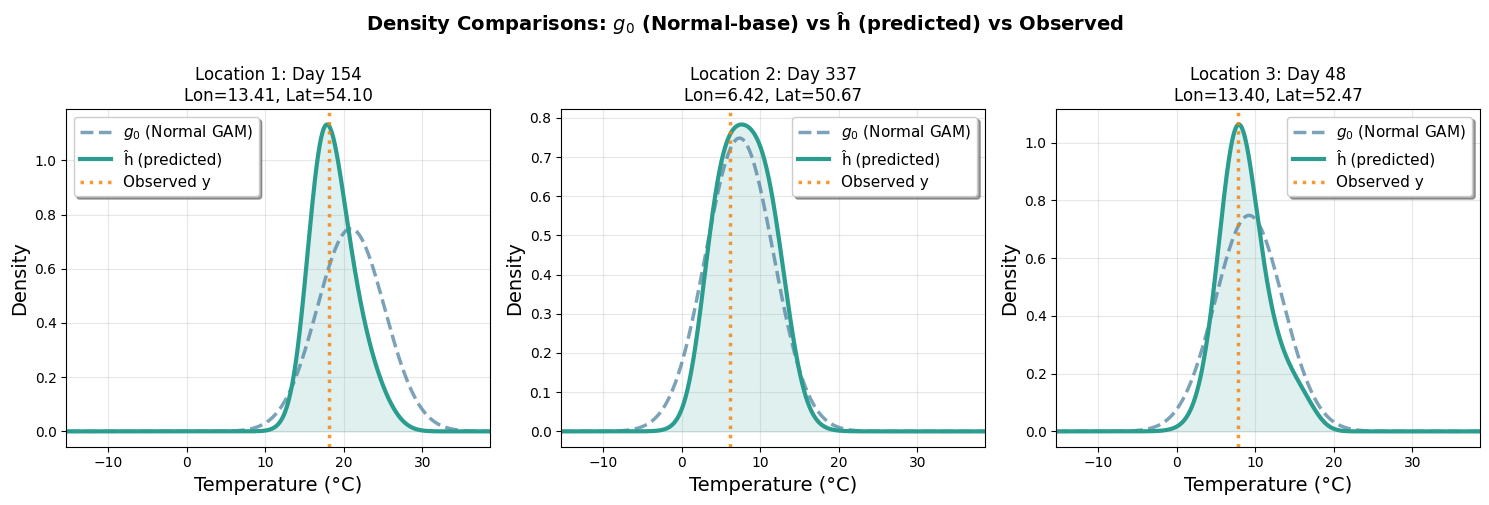

In [15]:
# Density comparisons at three held-out locations.
# Comparing: g_tilde (Normal GAM), ĥ (predicted), and observed y

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

random_indexes = torch.randperm(x_test.size(0), generator=torch.Generator())[[12, 123, 1234]]  # select 3 random indexes for test points
x_values = [x_test[random_indexes[0],:].cpu().numpy(), x_test[random_indexes[1],:].cpu().numpy(), x_test[random_indexes[2],:].cpu().numpy()]
y_values = [y_test[random_indexes[0]].cpu().numpy(), y_test[random_indexes[1]].cpu().numpy(), y_test[random_indexes[2]].cpu().numpy()]

# Define colors for different components
color_g = '#E63946'          # Red for g (t-distribution)
color_g_tilde = '#457B9D'    # Blue for g_tilde (Normal GAM)
color_h_hat = '#2A9D8F'      # Green for ĥ (predicted)
color_obs = '#F77F00'        # Orange for observed y

for i, (ax, x_star) in enumerate(zip(axes2, x_values)):
    # Use standardized values for prediction
    y_grid, g_vals, g_tilde_vals, h_hat, _, _ = model.predict_density(x_star, y_all.min(), y_all.max(), M=1000)


    # convert to original scale for display only 
    x_star_original = -np.log(2/(x_star+1)-1) * x_std + x_mean

    y_grid_original = y_grid * y_std + y_mean
    y_observed_original = y_values[i] * y_std + y_mean

    # Convert normalized time to day number within filtered range
    t_normalized = x_star_original[0]  # Time value in [0,1] for filtered data
    date_range_days = (df.index.max() - df.index.min()).days
    day_number = int(t_normalized * date_range_days)

    # Plot g_tilde (Normal base) and predicted density only
    ax.plot(y_grid_original, g_tilde_vals, '--', color=color_g_tilde, linewidth=2.5, alpha=0.7, label=f'$g_0$ (Normal GAM)')
    ax.plot(y_grid_original, h_hat, '-', color=color_h_hat, linewidth=3, label='ĥ (predicted)')
    ax.axvline(y_observed_original, color=color_obs, linestyle=':', linewidth=2.5, alpha=0.8, label='Observed y')
    
    # Styling
    ax.set_xlabel('Temperature (°C)', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.set_title(f'Location {i+1}: Day {day_number}\nLon={x_star_original[1]:.2f}, Lat={x_star_original[2]:.2f}', fontsize=12)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(y_grid_original.min(), y_grid_original.max())
    
    # Add subtle background fill under the predicted density curve
    ax.fill_between(y_grid_original, 0, h_hat, alpha=0.15, color=color_h_hat)

plt.suptitle(f'Density Comparisons: $g_0$ (Normal-base) vs ĥ (predicted) vs Observed', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("density_comparisons_weather_gpu.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
# Evaluate test log densities for GPDR and the original Normal base.

import time

def format_elapsed_time(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    minutes, seconds = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {seconds:.1f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.1f}s"

weather_logscore_start = time.perf_counter()

estimated_log_density_vals = 0
base_tilde_log_density_vals = 0


for i in range(len(x_test)):
    x_star = x_test[i].cpu().numpy()
    y_star = float(y_test[i].cpu().numpy().item())
    yg, gg, gg_tilde, hhat, _, _ = model.predict_density(x_star, y_min=y_all.min(), y_max=y_all.max(), M=1000)

    # Estimated log density at (x_star, y_star)
    # Interpolate to find the estimated density at y_star
    hhat_interp = np.interp(y_star, yg, hhat)
    log_hhat_star = np.log(hhat_interp)  # Add small constant to avoid log(0)
    estimated_log_density_vals += log_hhat_star
    
    # Base model g_tilde (Normal GAM) log density at (x_star, y_star)
    g_tilde_interp = np.interp(y_star, yg, gg_tilde)
    log_g_tilde_star = np.log(g_tilde_interp)  # Add small constant to avoid log(0)
    base_tilde_log_density_vals += log_g_tilde_star


    

print(f"Estimated Log Density (ĥ): {estimated_log_density_vals:.4f}")
print(f"Base Model Log Density ($g_0$, Normal): {base_tilde_log_density_vals:.4f}")

weather_logscore_time_seconds = time.perf_counter() - weather_logscore_start
print(f"GPDR log-score evaluation time: {format_elapsed_time(weather_logscore_time_seconds)}")


Estimated Log Density (ĥ): -10920.2537
Base Model Log Density ($g_0$, Normal): -13071.9185
GPDR log-score evaluation time: 4m 2.5s


In [17]:
# Pickle-save the optimized `model`
import pickle
with open("optimized_model_weather.pkl", "wb") as f:
    pickle.dump(model, f)


In [18]:
# Function to compute mean and credible intervals for base model g (t-distribution)
def get_base_g_stats(x_star):
    """
    Get mean and 95% credible interval for base model g (t-distribution).
    Uses scipy.stats.student_t.ppf for quantiles.
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    
    Returns:
    - mu, lower, upper: mean and 95% CI bounds
    """
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Get quantiles from t-distribution
    lower = student_t.ppf(0.025, DF, loc=mu, scale=SCALE_T)
    upper = student_t.ppf(0.975, DF, loc=mu, scale=SCALE_T)
    
    return mu, lower, upper


# Function to compute mean and credible intervals for base model g_tilde (Normal GAM)
def get_base_g_tilde_stats(x_star):
    """
    Get mean and 95% credible interval for base model g_tilde (Normal GAM).
    Uses scipy.stats.norm.ppf for quantiles with ORIGINAL_SIGMA_NORMAL (unscaled).
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    
    Returns:
    - mu, lower, upper: mean and 95% CI bounds
    """
    from scipy.stats import norm
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Get quantiles from normal distribution with ORIGINAL_SIGMA_NORMAL (unscaled)
    lower = norm.ppf(0.025, loc=mu, scale=ORIGINAL_SIGMA_NORMAL)
    upper = norm.ppf(0.975, loc=mu, scale=ORIGINAL_SIGMA_NORMAL)
    
    return mu, lower, upper


# Function to sample from the base model g_tilde (Normal GAM)
def sample_from_base_model(x_star, n_samples=1000):
    """
    Generate samples from the Normal GAM base model g_tilde at a given location/time.
    Uses ORIGINAL_SIGMA_NORMAL (unscaled).
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    - n_samples: int, number of samples to generate
    
    Returns:
    - samples: array of sampled temperatures
    """
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Sample from normal distribution with ORIGINAL_SIGMA_NORMAL (unscaled)
    samples = np.random.normal(loc=mu, scale=ORIGINAL_SIGMA_NORMAL, size=n_samples)
    
    return samples


# Function to sample from the updated model (for credible intervals)
def sample_from_updated_model(x_star, n_samples=1000, y_min=None, y_max=None, M=500):
    """
    Generate samples (Inverse transform sampling) from the updated GP density model at a given location/time.
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat]
    - n_samples: int, number of samples to generate
    - y_min, y_max: float, range for temperature grid (if None, use reasonable defaults)
    - M: int, number of grid points for density evaluation
    
    Returns:
    - samples: array of sampled temperatures
    """
    x_star = np.array(x_star)
    
    # Get density predictions
    y_grid, g_vals, g_tilde_vals, h_hat, _, _ = model.predict_density(
        x_star, y_min=y_min, y_max=y_max, M=M
    )
    
    # Normalize the density to ensure it's a proper probability distribution
    dy = y_grid[1] - y_grid[0]
    h_hat_norm = h_hat / (np.trapz(h_hat, dx=dy))
    
    # Cumulative distribution function
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)  # ensure it's properly bounded
    
    # Generate uniform random samples and use inverse transform sampling
    np.random.seed(42)  # for reproducibility
    u = np.random.uniform(0, 1, n_samples)
    
    # Interpolate to get temperature samples
    samples = np.interp(u, cdf, y_grid)
    
    return samples


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2778676333.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2778676333.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


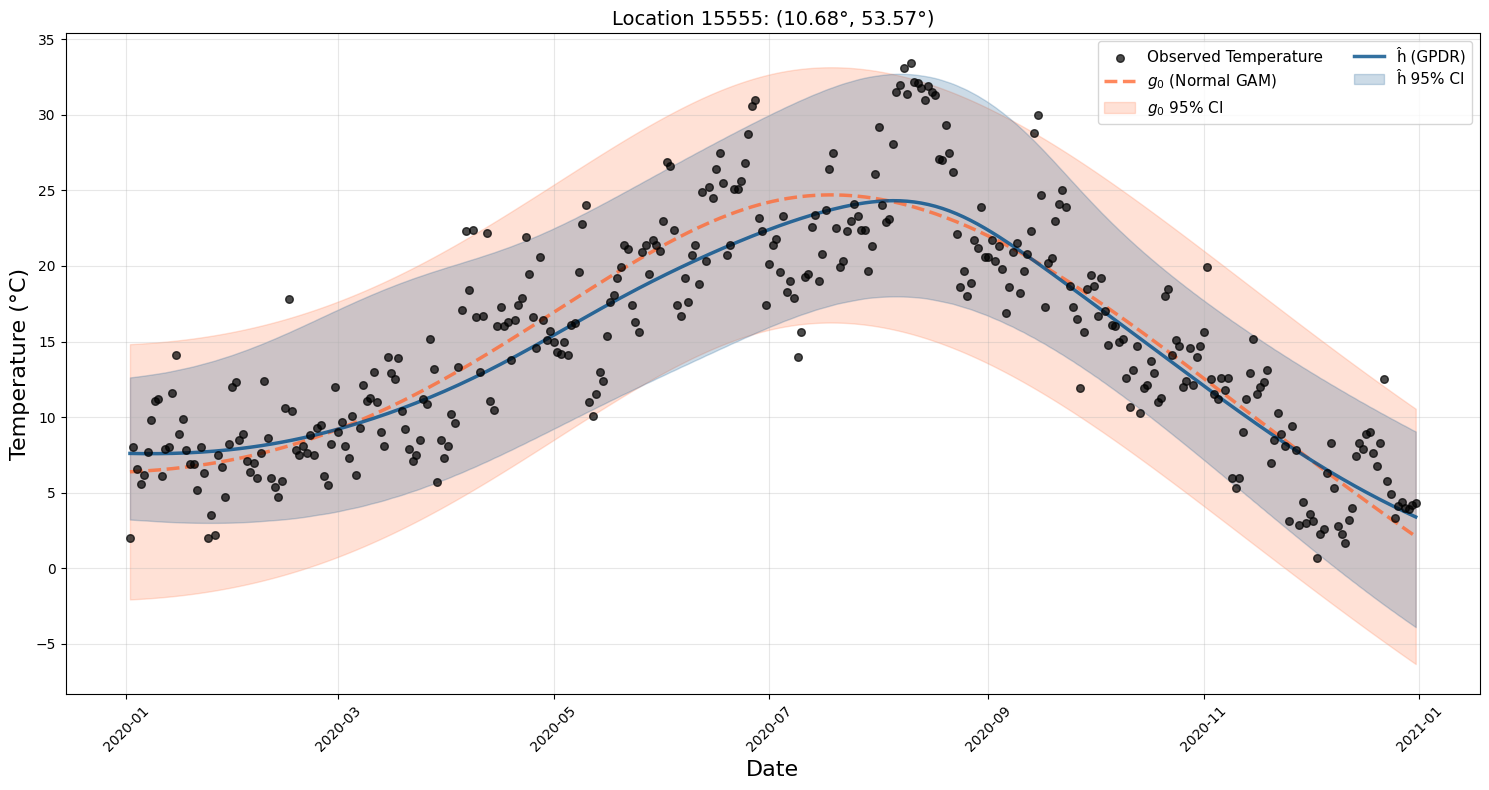

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2778676333.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2778676333.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


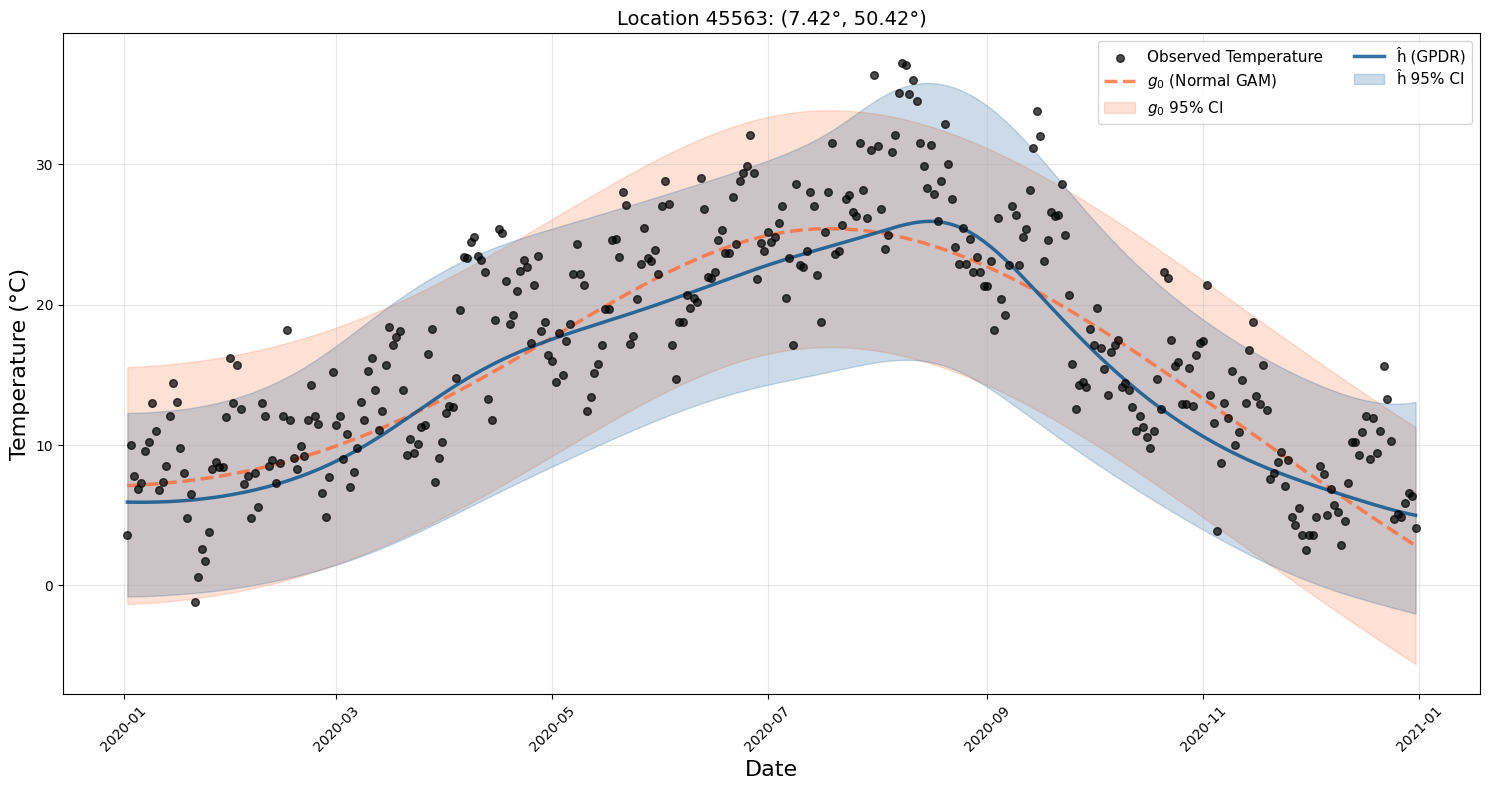

In [19]:
# Time series comparison for two locations: 45563 (7.4, 50.4) and 15555 (10.6, 53.5)
from scipy.stats import norm

for location_idx in [15555, 45563]:
    selected_location = df.iloc[location_idx]
    selected_lon = selected_location['longitude']
    selected_lat = selected_location['latitude']

    # Get data points at selected location
    location_mask = (np.abs(df['longitude'] - selected_lon) < 0.01) & (np.abs(df['latitude'] - selected_lat) < 0.01)
    location_data = df[location_mask].copy()

    if len(location_data) < 10:
        distances = np.sqrt((df['longitude'] - selected_lon)**2 + (df['latitude'] - selected_lat)**2)
        closest_indices = np.argsort(distances)[:100]
        location_data = df.iloc[closest_indices].copy()

    location_data = location_data.sort_values('t')
    X_loc_original = location_data[['t', 'longitude', 'latitude']].values
    y_loc_original = location_data['temperature'].values


    X_loc = (X_loc_original - x_mean) / x_std
    X_loc = 2/(1+np.exp(-X_loc)) - 1 
    y_loc = (y_loc_original - y_mean) / y_std

    # Base model g_tilde (Normal GAM) predictions only
    mu_g_tilde = []
    lower_g_tilde = []
    upper_g_tilde = []
    
    # Updated model predictions
    mu_updated = []
    lower_updated = []
    upper_updated = []

    for i, (t_val, lon_val, lat_val) in enumerate(X_loc):
        x_star = np.array([t_val, lon_val, lat_val])
        
        # Get g_tilde (Normal GAM) stats only
        mu, lower, upper = get_base_g_tilde_stats(x_star)
        mu_g_tilde.append(mu)
        lower_g_tilde.append(lower)
        upper_g_tilde.append(upper)
        
        # Get updated model stats using analytical density-based approach
        try:
            # Get density predictions
            yg, gg, gg_tilde, hhat, _, _ = model.predict_density(
                x_star, y_min=y_all.min().item()-20, y_max=y_all.max().item()+20, M=1000
            )
            
            # Normalize density
            dy = yg[1] - yg[0]
            h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
            
            # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
            mean_y = np.trapz(yg * h_hat_norm, dx=dy)
            mu_updated.append(mean_y)
            
            # Compute credible intervals using CDF
            cdf = np.cumsum(h_hat_norm) * dy
            cdf = np.clip(cdf, 0, 1)
            
            lower_quantile = np.interp(0.025, cdf, yg)
            upper_quantile = np.interp(0.975, cdf, yg)
            lower_updated.append(lower_quantile)
            upper_updated.append(upper_quantile)
        except:
            # Fallback to g_tilde if density prediction fails
            mu_updated.append(mu_g_tilde[-1])
            lower_updated.append(lower_g_tilde[-1])
            upper_updated.append(upper_g_tilde[-1])

    mu_g_tilde = np.array(mu_g_tilde)
    lower_g_tilde = np.array(lower_g_tilde)
    upper_g_tilde = np.array(upper_g_tilde)
    
    mu_updated = np.array(mu_updated)
    lower_updated = np.array(lower_updated)
    upper_updated = np.array(upper_updated)

    mu_g_tilde_original = mu_g_tilde * y_std + y_mean
    lower_g_tilde_original = lower_g_tilde * y_std + y_mean
    upper_g_tilde_original = upper_g_tilde * y_std + y_mean
    
    mu_updated_original = mu_updated * y_std + y_mean
    lower_updated_original = lower_updated * y_std + y_mean
    upper_updated_original = upper_updated * y_std + y_mean

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))

    ax.scatter(location_data.index, y_loc_original, alpha=0.7, s=30, color='black', 
              label='Observed Temperature', zorder=5)

    # Base model g_tilde (Normal GAM) only - Orange color for distinction
    ax.plot(location_data.index, mu_g_tilde_original, '--', linewidth=2.5, color='#FF6B35',
            label=f'$g_0$ (Normal GAM)', alpha=0.8)
    ax.fill_between(location_data.index, 
                    lower_g_tilde_original, 
                    upper_g_tilde_original, 
                    alpha=0.2, color='#FF6B35', label=f'$g_0$ 95% CI')

    # Updated model (GPDR) - Teal color for distinction
    ax.plot(location_data.index, mu_updated_original, '-', linewidth=2.5, color='#004E89',
            label='ĥ (GPDR)', alpha=0.8)
    ax.fill_between(location_data.index, 
                    lower_updated_original, 
                    upper_updated_original, 
                    alpha=0.2, color='#004E89', label='ĥ 95% CI')

    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Temperature (°C)', fontsize=16)
    ax.set_title(f'Location {location_idx}: ({selected_lon:.2f}°, {selected_lat:.2f}°)', fontsize=14)
    ax.legend(fontsize=11, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(f"time_effect_weather_gpu_{location_idx}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

Observed data points at fixed time (day=51th): 458 locations
Observed temperature range: [-7.5, 10.8]°C, mean: 7.3°C
Below 0°C count: 5 | Above 0°C count: 453
g (Normal GAM) predictions: [6.0, 9.9]°C, mean: 8.5°C
g uncertainty: 4.31°C (constant)
Computing ĥ (GPDR) predictions via sampling...


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/1260685461.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = h_hat / (np.trapz(h_hat, dx=dy))


ĥ (GPDR) predictions: [5.2, 10.6]°C, mean: 8.4°C
ĥ uncertainty: [1.73, 6.54]°C (spatially varying)

=== CREATING SPATIAL VISUALIZATION ===
Temperature color mapping: min=-7.5°C, p5=4.3°C, median=7.7°C, p95=9.5°C, max=10.8°C
GPDR uncertainty color range: [1.67, 6.68]°C


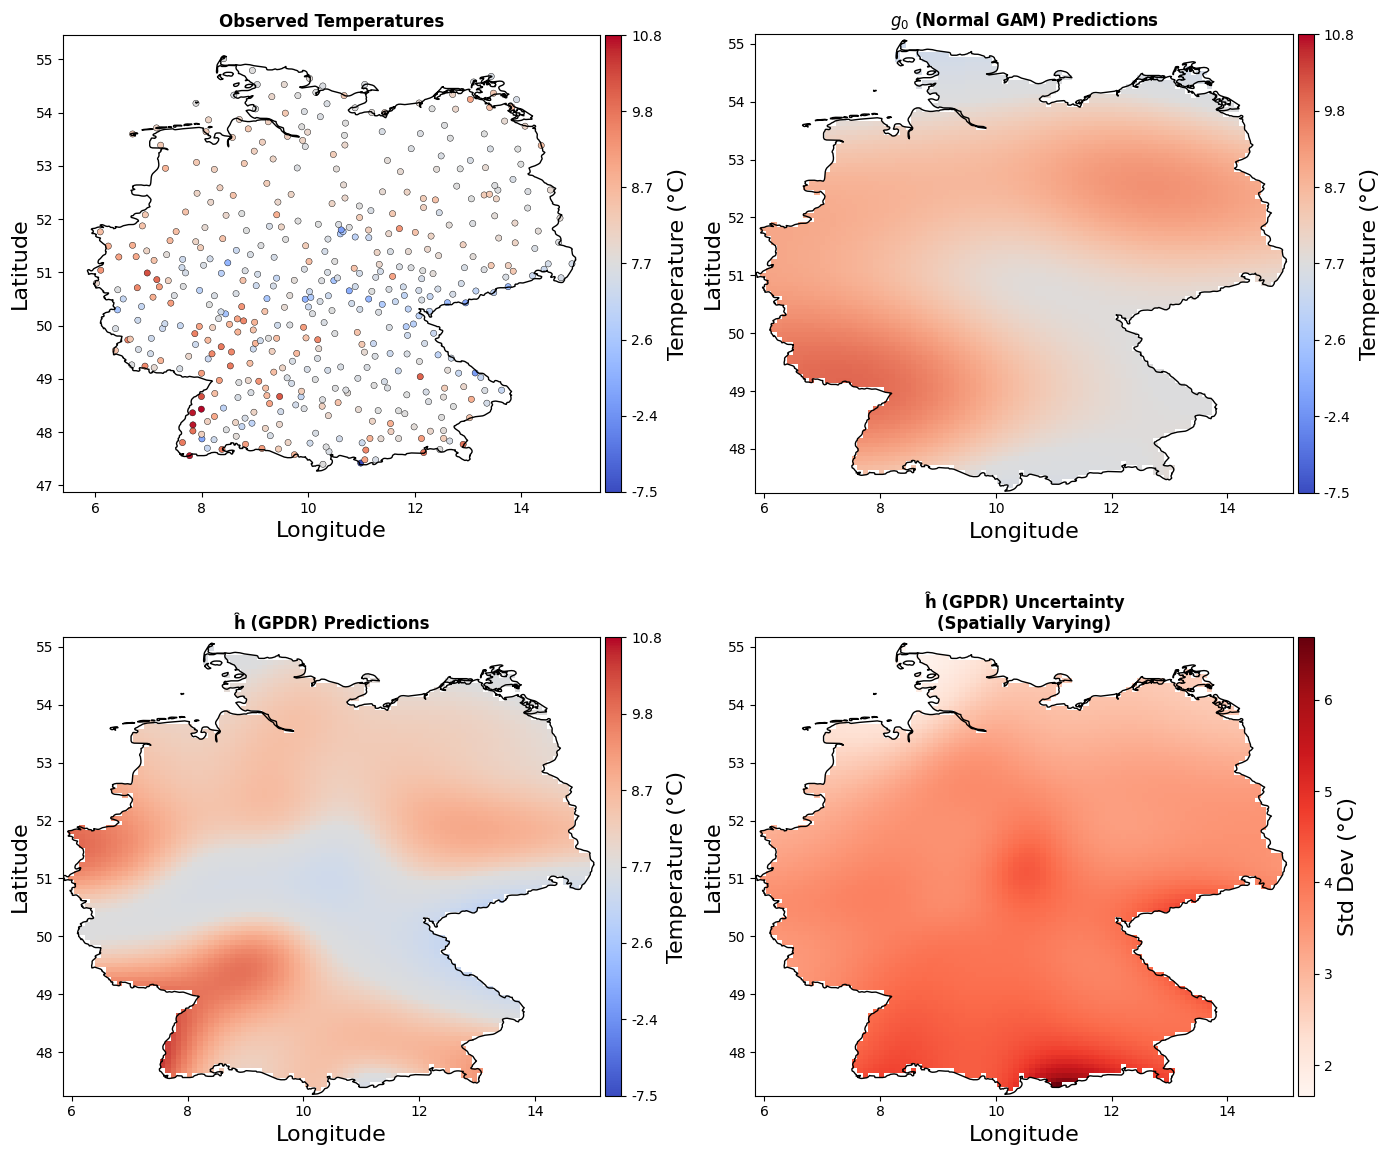

In [20]:
%matplotlib inline
from mpl_toolkits.axes_grid1 import make_axes_locatable
# SPATIAL ANALYSIS: Fixed time, varying locations only
# Comparing: Observed temperatures, g̃ (Normal GAM), ĥ (GPDR), and ĥ uncertainty
index_day = 51
fixed_time = df["t"].unique()[index_day-1]  # Single fixed time point throughout entire analysis

# Step 1: Get observed data at the fixed time
obs_data = df[df["t"]==fixed_time].copy()

# Step 2: Select diverse locations for analysis (spatial stratification)
lons_all = obs_data['longitude'].values
lats_all = obs_data['latitude'].values
temps_obs_all = obs_data['temperature'].values

lons = lons_all
lats = lats_all
temps_obs = temps_obs_all

print(f"Observed data points at fixed time (day={index_day}th): {len(temps_obs)} locations")
print(f"Observed temperature range: [{temps_obs.min():.1f}, {temps_obs.max():.1f}]°C, mean: {temps_obs.mean():.1f}°C")
print(f"Below 0°C count: {(temps_obs < 0).sum()} | Above 0°C count: {(temps_obs >= 0).sum()}")

# Step 3: Model predictions at fixed time, varying locations

# Create input: fixed time for all locations (original scale)
X_fixed_time_original = np.column_stack([
    np.full(len(lons), fixed_time),  # Same fixed time for ALL locations
    lons,                            # Different longitudes
    lats                             # Different latitudes
])

# Standardize input for model predictions and apply the map if model was trained on mapped data
X_fixed_time = (X_fixed_time_original - x_mean) / x_std
X_fixed_time = 2/(1+np.exp(-X_fixed_time)) - 1  # Apply map to [-1,1] if model was trained on mapped data

# g_tilde (Normal GAM) predictions at station points
mu_g_tilde = gam.predict(X_fixed_time)
sigma_g_tilde = ORIGINAL_SIGMA_NORMAL  # Constant uncertainty from Normal GAM (original, not scaled)

mu_g_tilde_original = mu_g_tilde * y_std + y_mean
sigma_g_tilde_original = sigma_g_tilde * y_std

print(f"g (Normal GAM) predictions: [{mu_g_tilde_original.min():.1f}, {mu_g_tilde_original.max():.1f}]°C, mean: {mu_g_tilde_original.mean():.1f}°C")
print(f"g uncertainty: {sigma_g_tilde_original:.2f}°C (constant)")

# Updated model predictions via sampling at station points
print("Computing ĥ (GPDR) predictions via sampling...")
mu_updated = []
sigma_updated = []

for i, (lon, lat) in enumerate(zip(lons, lats)):
    x_star_original = np.array([fixed_time, lon, lat])
    # apply standardization and map if model was trained on mapped data
    x_star = (x_star_original - x_mean) / x_std
    x_star = 2/(1+np.exp(-x_star)) - 1  # Sample from updated model to get mean and std

    samples = sample_from_updated_model(x_star, n_samples=500, y_min=y_all.min().item(), y_max=y_all.max().item())
    mu_updated.append(np.mean(samples))
    sigma_updated.append(np.std(samples))

mu_updated = np.array(mu_updated)
sigma_updated = np.array(sigma_updated)

# Convert to original scale
mu_updated_original = mu_updated * y_std + y_mean
sigma_updated_original = sigma_updated * y_std

print(f"ĥ (GPDR) predictions: [{mu_updated_original.min():.1f}, {mu_updated_original.max():.1f}]°C, mean: {mu_updated_original.mean():.1f}°C")
print(f"ĥ uncertainty: [{sigma_updated_original.min():.2f}, {sigma_updated_original.max():.2f}]°C (spatially varying)")

# Step 4: Create spatial visualization
print("\n=== CREATING SPATIAL VISUALIZATION ===")

# Create grid for heatmap visualization
lon_range = lons.max() - lons.min()
lat_range = lats.max() - lats.min()
lon_grid = np.linspace(lons.min() - 0.02*lon_range, lons.max() + 0.02*lon_range, 100)
lat_grid = np.linspace(lats.min() - 0.02*lat_range, lats.max() + 0.02*lat_range, 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Apply Germany boundary mask first to skip outside points
x_flat = lon_mesh.ravel()
y_flat = lat_mesh.ravel()
xy = np.column_stack([x_flat, y_flat])

outside = np.ones(xy.shape[0], dtype=bool)
for geom in gdf.geometry:
    if isinstance(geom, Polygon):
        inside_poly = points_in_polygon_path(xy, geom)
        outside &= ~inside_poly  
    elif isinstance(geom, MultiPolygon):
        inside_any = np.zeros(xy.shape[0], dtype=bool)
        for part in geom.geoms:
            inside_any |= points_in_polygon_path(xy, part)
        outside &= ~inside_any
    else:
        continue

mask = outside.reshape(lon_mesh.shape)

# g̃ (Normal GAM) predictions on grid (original scale grid, standardize for prediction)
X_grid_original = np.column_stack([np.full(lon_mesh.size, fixed_time), lon_mesh.ravel(), lat_mesh.ravel()])
# standardize and apply map if model was trained on mapped data
X_grid = (X_grid_original - x_mean) / x_std
X_grid = 2/(1+np.exp(-X_grid)) - 1  # Apply map to [-1,1] if model was trained on mapped data
mu_g_tilde_grid = gam.predict(X_grid).reshape(lon_mesh.shape)
sigma_g_tilde_grid = np.full_like(mu_g_tilde_grid, ORIGINAL_SIGMA_NORMAL)

# Convert to original scale
mu_g_tilde_grid_original = mu_g_tilde_grid * y_std + y_mean
sigma_g_tilde_grid_original = sigma_g_tilde_grid * y_std

# ĥ (GPDR) predictions on grid (sample-based, compute only within boundary)
mu_updated_grid = np.full(lon_mesh.shape, np.nan)
sigma_updated_grid = np.full(lon_mesh.shape, np.nan)
valid_idx = np.where(~mask.ravel())[0]
n_samples_grid = 100

for k, idx in enumerate(valid_idx):
    samples = sample_from_updated_model(X_grid[idx], n_samples=n_samples_grid, y_min=y_all.min().item(), y_max=y_all.max().item())
    mu_updated_grid.ravel()[idx] = np.mean(samples)
    sigma_updated_grid.ravel()[idx] = np.std(samples)

# Convert to original scale
mu_updated_grid_original = mu_updated_grid * y_std + y_mean
sigma_updated_grid_original = sigma_updated_grid * y_std

# Mask arrays for plotting
mu_g_tilde_masked = np.ma.array(mu_g_tilde_grid_original, mask=mask)
mu_updated_masked = np.ma.array(mu_updated_grid_original, mask=mask)
sigma_g_tilde_masked = np.ma.array(sigma_g_tilde_grid_original, mask=mask)
sigma_updated_masked = np.ma.array(sigma_updated_grid_original, mask=mask)

# 4-panel spatial comparison plot (2x2 grid): Observed, g̃, ĥ predictions, and ĥ uncertainty
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Adaptive temperature color range based on percentiles to enhance main data range
# Use percentiles to focus color variation on the bulk of the data
temp_p5 = np.percentile(temps_obs, 5)   # 5th percentile
temp_p95 = np.percentile(temps_obs, 95)  # 95th percentile
temp_median = np.median(temps_obs)

# Create a centered normalization that emphasizes the main data range
# TwoSlopeNorm allows asymmetric scaling around the center
from matplotlib.colors import TwoSlopeNorm
temp_norm = TwoSlopeNorm(vmin=temps_obs.min(), vcenter=temp_median, vmax=temps_obs.max())

print(f"Temperature color mapping: min={temps_obs.min():.1f}°C, p5={temp_p5:.1f}°C, median={temp_median:.1f}°C, p95={temp_p95:.1f}°C, max={temps_obs.max():.1f}°C")

# Uncertainty color range - use only GPDR uncertainty range for better visual contrast
sigma_vmin = np.nanmin(sigma_updated_masked)
sigma_vmax = np.nanmax(sigma_updated_masked)
print(f"GPDR uncertainty color range: [{sigma_vmin:.2f}, {sigma_vmax:.2f}]°C")

# Panel 1: Observed temperatures at fixed time (scatter of stations)
ax1 = axes[0, 0]
sc1 = ax1.scatter(lons, lats, c=temps_obs, cmap='coolwarm', norm=temp_norm, s=20, edgecolors='k', linewidths=0.3)
gdf.boundary.plot(ax=ax1, color='k', linewidth=1.0)
ax1.set_title(f'Observed Temperatures', fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=16)
ax1.set_ylabel('Latitude', fontsize=16)
ax1.set_aspect('equal')

# Colorbar for panel 1
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.05)
cb1 = fig.colorbar(sc1, cax=cax1)
cb1.set_label('Temperature (°C)', fontsize=16)

# Set evenly spaced ticks for all temperature colorbars
norm_positions = np.linspace(0, 1, 7)  # 7 evenly spaced positions visually
temp_tick_values = [temp_norm.inverse(p) for p in norm_positions]
cb1.set_ticks(temp_tick_values)
cb1.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 2: g̃ (Normal GAM) predictions (heatmap on grid)
ax2 = axes[0, 1]
im2 = ax2.imshow(mu_g_tilde_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='coolwarm', norm=temp_norm, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax2, color='k', linewidth=1.0)
ax2.set_title(f'$g_0$ (Normal GAM) Predictions', fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=16)
ax2.set_ylabel('Latitude', fontsize=16)
ax2.set_aspect('equal')

# Colorbar for panel 2
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.05)
cb2 = fig.colorbar(im2, cax=cax2)
cb2.set_label('Temperature (°C)', fontsize=16)
cb2.set_ticks(temp_tick_values)
cb2.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 3: Updated model predictions (heatmap on grid)
ax3 = axes[1, 0]
im3 = ax3.imshow(mu_updated_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='coolwarm', norm=temp_norm, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax3, color='k', linewidth=1.0)
ax3.set_title('ĥ (GPDR) Predictions', fontweight='bold')
ax3.set_xlabel('Longitude', fontsize=16)
ax3.set_ylabel('Latitude', fontsize=16)
ax3.set_aspect('equal')

# Colorbar for panel 3
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="3%", pad=0.05)
cb3 = fig.colorbar(im3, cax=cax3)
cb3.set_label('Temperature (°C)', fontsize=16)
cb3.set_ticks(temp_tick_values)
cb3.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 4: Updated model uncertainty (spatially varying)
ax4 = axes[1, 1]
im4 = ax4.imshow(sigma_updated_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='Reds', vmin=sigma_vmin, vmax=sigma_vmax, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax4, color='k', linewidth=1.0)
ax4.set_title('ĥ (GPDR) Uncertainty\n(Spatially Varying)', fontweight='bold')
ax4.set_xlabel('Longitude', fontsize=16)
ax4.set_ylabel('Latitude', fontsize=16)
ax4.set_aspect('equal')

# Colorbar for panel 4 (consistent with panel 3)
divider4 = make_axes_locatable(ax4)
cax4 = divider4.append_axes("right", size="3%", pad=0.05)
cb4 = fig.colorbar(im4, cax=cax4)
cb4.set_label('Std Dev (°C)', fontsize=16)

plt.tight_layout()

plt.savefig("spatial_analysis_fixed_time_only.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
# === Prediction Error Summary at station points for spatial analysis ===
def metrics(y_true, y_pred):
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true)**2)))
    return mae, rmse

# Compute g (t-distribution) predictions
mu_g = []
for i in range(len(X_fixed_time)):
    x_star = X_fixed_time[i]
    mu, _, _ = get_base_g_stats(x_star)
    mu_g.append(mu)
mu_g = np.array(mu_g)
mu_g_original = mu_g * y_std + y_mean

# Compute metrics for all three models
g_mae, g_rmse = metrics(temps_obs, mu_g_original)
g_tilde_mae, g_tilde_rmse = metrics(temps_obs, mu_g_tilde_original)
h_mae, h_rmse = metrics(temps_obs, mu_updated_original)

print("\n=== Prediction Error Summary ===")
print(f"g (t-dist)     -> MAE: {g_mae:.3f} °C | RMSE: {g_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_g_original - temps_obs)):.1f}")
print(f"g̃ (Normal GAM) -> MAE: {g_tilde_mae:.3f} °C | RMSE: {g_tilde_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_g_tilde_original - temps_obs)):.1f}")
print(f"ĥ (GPDR)       -> MAE: {h_mae:.3f} °C | RMSE: {h_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_updated_original - temps_obs)):.1f}")


=== Prediction Error Summary ===
g (t-dist)     -> MAE: 1.412 °C | RMSE: 2.155 °C | Total Error: 646.9
g̃ (Normal GAM) -> MAE: 1.412 °C | RMSE: 2.155 °C | Total Error: 646.9
ĥ (GPDR)       -> MAE: 1.306 °C | RMSE: 1.955 °C | Total Error: 598.2


In [22]:
# Model Comparison Diagnostics with UNSTANDARDIZED Data

# Define parameters
import time

weather_metric_start = time.perf_counter()
n_test = len(x_test)


# Initialize storage for diagnostics (in original scale) - 95% CI only
updated_predictions_orig = []
updated_intervals_orig_lower = []
updated_intervals_orig_upper = []

base_g_tilde_predictions_orig = []
base_g_tilde_intervals_orig_lower = []
base_g_tilde_intervals_orig_upper = []

y_obs_orig = []

for i in range(n_test):
    x_star_std = x_test[i].cpu().numpy()  # Standardized x
    y_star_std = float(y_test[i].cpu().numpy().item())  # Standardized y
    
    # Convert y back to original scale for observation
    y_star_orig = y_star_std * y_std + y_mean
    y_obs_orig.append(y_star_orig)
    
    # Updated Model (ĥ) - Density-based approach
    # Get density predictions (in standardized space)
    yg, gg, gg_tilde, hhat, _, _ = model.predict_density(
        x_star_std, y_min=y_all.min().item(), y_max=y_all.max().item(), M=1000
    )
    
    # Normalize density
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
    
    # Numerical expectation: E[Y|X] = integral y * h(y|x) dy on the standardized scale.
    mean_y_std = np.trapz(yg * h_hat_norm, dx=dy)
    
    # Convert to original scale
    mean_y_orig = mean_y_std * y_std + y_mean
    updated_predictions_orig.append(mean_y_orig)
    
    # Compute 95% credible interval using CDF
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    lower_q = 0.025  # (1 - 0.95) / 2
    upper_q = 0.975  # 1 - 0.025
    lower_quantile_std = np.interp(lower_q, cdf, yg)
    upper_quantile_std = np.interp(upper_q, cdf, yg)
    
    # Convert to original scale
    lower_quantile_orig = lower_quantile_std * y_std + y_mean
    upper_quantile_orig = upper_quantile_std * y_std + y_mean
    updated_intervals_orig_lower.append(lower_quantile_orig)
    updated_intervals_orig_upper.append(upper_quantile_orig)
    
    # Base Model g̃ (Normal GAM) - using ORIGINAL_SIGMA_NORMAL (unscaled)
    x_star_std_reshape = np.array(x_star_std).reshape(1, -1)
    mu_std = gam.predict(x_star_std_reshape)[0]
    
    # Convert mean to original scale
    mu_orig = mu_std * y_std + y_mean
    base_g_tilde_predictions_orig.append(mu_orig)
    
    # Compute 95% interval using ORIGINAL_SIGMA_NORMAL (unscaled)
    lower_std = norm.ppf(0.025, loc=mu_std, scale=ORIGINAL_SIGMA_NORMAL)
    upper_std = norm.ppf(0.975, loc=mu_std, scale=ORIGINAL_SIGMA_NORMAL)
    
    # Convert to original scale
    lower_orig = lower_std * y_std + y_mean
    upper_orig = upper_std * y_std + y_mean
    base_g_tilde_intervals_orig_lower.append(lower_orig)
    base_g_tilde_intervals_orig_upper.append(upper_orig)

# Convert to numpy arrays
y_obs_orig = np.array(y_obs_orig)
updated_predictions_orig = np.array(updated_predictions_orig)
base_g_tilde_predictions_orig = np.array(base_g_tilde_predictions_orig)

updated_intervals_orig_lower = np.array(updated_intervals_orig_lower)
updated_intervals_orig_upper = np.array(updated_intervals_orig_upper)
base_g_tilde_intervals_orig_lower = np.array(base_g_tilde_intervals_orig_lower)
base_g_tilde_intervals_orig_upper = np.array(base_g_tilde_intervals_orig_upper)

# Compute Diagnostics (in original temperature scale)

# RMSE (Root Mean Squared Error) in °C
rmse_g_tilde_orig = np.sqrt(np.mean((base_g_tilde_predictions_orig - y_obs_orig)**2))
rmse_updated_orig = np.sqrt(np.mean((updated_predictions_orig - y_obs_orig)**2))

# Display Results
print("\n" + "="*70)
print("MODEL COMPARISON DIAGNOSTICS (Weather Data - ORIGINAL SCALE)")
print("="*70)

print(f"\nData Scale Information:")
print(f"   Observed test range: [{y_obs_orig.min():.2f}, {y_obs_orig.max():.2f}] °C")

print("\nRMSE (Root Mean Squared Error) in °C:")
print(f"   $g_0$ (Normal GAM): {rmse_g_tilde_orig:.4f} °C")
print(f"   ĥ (GPDR):       {rmse_updated_orig:.4f} °C")
print()

# Display 95% CI coverage and interval length
coverage_g_tilde = np.mean((y_obs_orig >= base_g_tilde_intervals_orig_lower) & 
                           (y_obs_orig <= base_g_tilde_intervals_orig_upper))
coverage_updated = np.mean((y_obs_orig >= updated_intervals_orig_lower) & 
                           (y_obs_orig <= updated_intervals_orig_upper))

avg_length_g_tilde = np.mean(base_g_tilde_intervals_orig_upper - base_g_tilde_intervals_orig_lower)
avg_length_updated = np.mean(updated_intervals_orig_upper - updated_intervals_orig_lower)

print(f"95% CI Coverage:")
print(f"   $g_0$ (Normal GAM): {coverage_g_tilde:.4f}")
print(f"   ĥ (GPDR):       {coverage_updated:.4f}")

print(f"\n95% CI Avg Width (°C):")
print(f"   $g_0$ (Normal GAM): {avg_length_g_tilde:.4f} °C")
print(f"   ĥ (GPDR):       {avg_length_updated:.4f} °C")

weather_metric_time_seconds = time.perf_counter() - weather_metric_start
gpdr_prediction_time_seconds = globals().get("weather_logscore_time_seconds", 0.0) + weather_metric_time_seconds
gpdr_prediction_time = format_elapsed_time(gpdr_prediction_time_seconds)
print(f"GPDR prediction/evaluation time: {gpdr_prediction_time}")


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2173686186.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_48806/2173686186.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y_std = np.trapz(yg * h_hat_norm, dx=dy)



MODEL COMPARISON DIAGNOSTICS (Weather Data - ORIGINAL SCALE)

Data Scale Information:
   Observed test range: [-15.30, 37.20] °C

RMSE (Root Mean Squared Error) in °C:
   $g_0$ (Normal GAM): 4.2602 °C
   ĥ (GPDR):       4.0355 °C

95% CI Coverage:
   $g_0$ (Normal GAM): 0.9551
   ĥ (GPDR):       0.9548

95% CI Avg Width (°C):
   $g_0$ (Normal GAM): 16.8838 °C
   ĥ (GPDR):       15.0435 °C
GPDR prediction/evaluation time: 8m 49.9s


In [23]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Median Heuristic Optimization
# # ============================
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform
# import time

# # Define interpretable parameter ranges
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED at 1000 (not part of search)
# m_induce_fixed = 1000

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4)  # 4D: log_sigma2, log_lx2, log_lz2, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")

# # LHS samples are already in [0, 1]^4, which is perfect for distance optimization
# # We'll work in normalized space, then convert to actual hyperparameters at the end
# candidates_normalized = lhs_samples.copy()  # Shape: (n_candidates, 4)

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# # Working in normalized [0, 1]^4 space ensures all dimensions are equally weighted
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Now convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta,
#         'm_induce': m_induce_fixed  # Fixed at 1000
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")


In [24]:
# # Save candidates for later use
# import pickle
# with open("hyperparameter_candidates_weather.pkl", "wb") as f:
#     pickle.dump(candidates, f)

In [25]:
# # load candidates
# with open("hyperparameter_candidates_weather.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [26]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # with Bayesian Optimization
# # BO objective: average validation log score
# # ============================

# import time
# import math
# import pickle
# import numpy as np
# import torch
# import torch.optim as optim
# from dataclasses import dataclass
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
# from scipy.stats import norm

# BAD_LOG_SCORE = -1e12


# # ----------------------------
# # CV kernel params helper
# # ----------------------------
# @dataclass
# class KernelParamsCV:
#     log_sigma2: float
#     log_lx2: float
#     log_lz2: float
    
#     def get_lx2(self, device, dtype):
#         """Create the same x-lengthscale in every x dimension."""
#         log_lx2_tensor = torch.full((dim_x,), self.log_lx2, device=device, dtype=dtype)
#         return torch.exp(log_lx2_tensor)
    
#     @property
#     def sigma2(self):
#         return math.exp(self.log_sigma2)
    
#     @property
#     def lx2(self):
#         return math.exp(self.log_lx2)
    
#     @property
#     def lz2(self):
#         return math.exp(self.log_lz2)


# # ----------------------------
# # Density summary helper
# # ----------------------------
# def summarize_density_on_grid(y_grid, h_hat, y_obs, alpha=0.05):
#     """
#     Given a predictive density h_hat on y_grid, compute:
#       - log score at y_obs
#       - equal-tailed coverage indicator
#       - equal-tailed interval length
#     Return None if the density contains non-finite values.
#     """
#     y_grid = np.asarray(y_grid)
#     h_hat = np.asarray(h_hat)

#     if (not np.all(np.isfinite(y_grid))) or (not np.all(np.isfinite(h_hat))):
#         return None

#     dy = np.diff(y_grid)
#     wts = np.zeros_like(y_grid)
#     wts[0] = dy[0] / 2.0
#     wts[-1] = dy[-1] / 2.0
#     wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

#     prob = h_hat * wts
#     prob_sum = prob.sum()
#     if (not np.isfinite(prob_sum)) or (prob_sum <= 0):
#         prob = np.ones_like(prob) / prob.size
#     else:
#         prob = prob / prob_sum

#     cdf = np.cumsum(prob)
#     cdf = np.clip(cdf, 0.0, 1.0)
#     cdf[-1] = 1.0

#     hhat_interp = np.interp(y_obs, y_grid, h_hat)
#     if not np.isfinite(hhat_interp):
#         return None

#     log_score = np.log(max(hhat_interp, 1e-12))
#     lower = np.interp(alpha / 2.0, cdf, y_grid)
#     upper = np.interp(1.0 - alpha / 2.0, cdf, y_grid)

#     if not np.isfinite(log_score + lower + upper):
#         return None

#     covered = float((y_obs >= lower) and (y_obs <= upper))
#     interval_length = float(upper - lower)

#     return float(log_score), covered, interval_length


# # ----------------------------
# # Inducing-point helpers reused across CV candidates
# # ----------------------------
# def compute_inducing_points_from_x(x_train_fold, m_induce, device):
#     """
#     Compute inducing-point x locations with k-means once per fold.
#     """
#     n_per_dim = int(round(m_induce ** (1/(dim_x+1))))
#     totalnum_xpoints = n_per_dim ** dim_x
#     optimal_k = totalnum_xpoints

#     cluster_ids_x, cluster_centers = kmeans(
#         X=x_train_fold, num_clusters=optimal_k, distance='euclidean', device=device
#     )

#     points_allcluster = torch.zeros((0, dim_x), device=device, dtype=x_train_fold.dtype)
#     for u in range(optimal_k):
#         cluster_center = torch.tensor(cluster_centers[u], device=device, dtype=x_train_fold.dtype)
#         points_allcluster = torch.cat([points_allcluster, cluster_center.unsqueeze(0)], dim=0)

#     x_grid = points_allcluster[1:, :]
#     return x_grid, n_per_dim


# def create_inducing_points_from_x_grid(x_grid, n_per_dim, device, dtype):
#     """
#     Create full (x,z) inducing points from a precomputed x-grid and a z-grid.
#     """
#     z_grid = torch.linspace(1e-5, 1-1e-5, n_per_dim, device=device, dtype=dtype)
#     x_grid_expand = x_grid[:, None, :].expand(x_grid.size(0), n_per_dim, dim_x)
#     z_grid_expand = z_grid[None, :, None].expand(x_grid.size(0), n_per_dim, 1)
#     Vu = torch.cat([x_grid_expand, z_grid_expand], dim=2).reshape(
#         x_grid.size(0) * n_per_dim, dim_x + 1
#     )
#     return Vu


# def create_model_with_precomputed_inducing(
#     x_train_fold, y_train_fold, x_grid_precomputed, n_per_dim, kp, beta, device, C_cv=2
# ):
#     """
#     Create LogisticGPMixtureDiag model while bypassing repeated k-means.
#     This keeps the updated mixture-weight / Goldberger-KL / Gumbel-FZZ objective.
#     """
#     Vu_precomputed = create_inducing_points_from_x_grid(
#         x_grid_precomputed, n_per_dim, device, x_train_fold.dtype
#     )

#     model = LogisticGPMixtureDiag.__new__(LogisticGPMixtureDiag)
#     nn.Module.__init__(model)

#     model.x = x_train_fold.detach()
#     model.y = y_train_fold.detach()
#     model.n = x_train_fold.numel()
#     model.C = C_cv
#     model.beta = beta
#     model.gumbel_tau = 0.5
#     model.kern = RBF_SE_ARD(kp, device=device, dtype=x_train_fold.dtype)

#     z = to_z_from_y(model.y, model.x)
#     z = torch.clamp(z, 1e-5, 1-1e-5)
#     model.V = torch.cat([model.x, z.reshape(-1, 1)], dim=1)

#     model.Vu = Vu_precomputed
#     model.m = model.Vu.size(0)

#     model.g, model.gy, model.gyy = base_g_terms(model.y, model.x)

#     model.K11uu = model.kern.delta_11(model.Vu, model.Vu)
#     model.K11uu_inv, model.K11uu_chol = chol_inv(model.K11uu)
#     model.A = model.kern.delta_11(model.V, model.Vu) @ model.K11uu_inv
#     model.B = model.kern.delta_21(model.V, model.Vu) @ model.K11uu_inv
#     model.A2 = model.A**2
#     model.A2T_g2_over_n = model.A2.T @ ((model.g**2) / model.n)

#     model.logits = nn.Parameter(torch.randn(model.C, device=device, dtype=x_train_fold.dtype))
#     model.mus = nn.Parameter(torch.randn(model.C, model.m, device=device, dtype=x_train_fold.dtype))
#     init_log_std = math.log(0.35)
#     model.s_params = nn.Parameter(
#         torch.full((model.C, model.m), init_log_std, device=device, dtype=x_train_fold.dtype)
#     )

#     model.warm_start_mu()
#     return model.to(device)


# # ----------------------------
# # Train one fold and evaluate on its validation subset
# # ----------------------------
# def train_and_evaluate_model_cv(
#     log_sigma2, log_lx2, log_lz2, beta,
#     x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#     x_grid_precomputed, n_per_dim
# ):
#     """
#     Train model on one training fold and evaluate log-score / coverage / length
#     on the corresponding validation subset.
#     """
#     kp = KernelParamsCV(log_sigma2=log_sigma2, log_lx2=log_lx2, log_lz2=log_lz2)

#     try:
#         model_cv = create_model_with_precomputed_inducing(
#             x_train_fold, y_train_fold, x_grid_precomputed, n_per_dim, kp, beta, device, C_cv=2
#         )

#         optimizer_cv = optim.Adam(model_cv.parameters(), lr=0.5)

#         num_iterations = 5000
#         averaging_window = 500
#         start_averaging = num_iterations - averaging_window
#         averaged_params = None
#         num_averaged = 0

#         for iteration in range(num_iterations):
#             optimizer_cv.zero_grad()
#             F, info = model_cv.forward_objective()

#             if not torch.isfinite(F):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_objective",
#                 }

#             F.backward()
#             optimizer_cv.step()

#             if iteration >= start_averaging:
#                 with torch.no_grad():
#                     if averaged_params is None:
#                         averaged_params = {
#                             name: torch.zeros_like(param.data)
#                             for name, param in model_cv.named_parameters()
#                         }
#                     for name, param in model_cv.named_parameters():
#                         averaged_params[name] += param.data
#                     num_averaged += 1

#         if averaged_params is not None and num_averaged > 0:
#             with torch.no_grad():
#                 for name, param in model_cv.named_parameters():
#                     param.data.copy_(averaged_params[name] / num_averaged)

#         total_log_score = 0.0
#         coverage_hits = []
#         interval_lengths = []

#         for i in range(len(x_val_fold)):
#             x_star = x_val_fold[i, :].cpu().numpy()
#             y_star = float(y_val_fold[i].cpu().numpy().item())

#             y_grid, g_vals, g_tilde_vals, h_hat, _, f_vals = model_cv.predict_density(
#                 x_star, y_min=y_all.min(), y_max=y_all.max(), M=1000
#             )

#             if (not np.all(np.isfinite(h_hat))) or (not np.all(np.isfinite(f_vals))):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_prediction_density",
#                 }

#             summary_i = summarize_density_on_grid(y_grid, h_hat, y_star, alpha=0.05)

#             if summary_i is None:
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "invalid_density_summary",
#                 }

#             log_score_i, covered_i, interval_len_i = summary_i
#             total_log_score += log_score_i
#             coverage_hits.append(covered_i)
#             interval_lengths.append(interval_len_i)

#         return {
#             "log_score": float(total_log_score),
#             "coverage95": float(np.mean(coverage_hits)),
#             "avg_length95": float(np.mean(interval_lengths)),
#             "failed": False,
#             "fail_reason": "",
#         }

#     except Exception as e:
#         print(f"\nError in CV: {e}")
#         return {
#             "log_score": BAD_LOG_SCORE,
#             "coverage95": 0.0,
#             "avg_length95": np.inf,
#             "failed": True,
#             "fail_reason": str(e),
#         }


# # ----------------------------
# # Prepare 3-fold CV splits with subsampled validation sets
# # ----------------------------
# n_train = len(x_train)
# fold_size = n_train // 3
# cv_seed = 42

# cv_indices = torch.randperm(n_train, generator=torch.Generator().manual_seed(cv_seed))

# fold_indices = [
#     cv_indices[:fold_size],
#     cv_indices[fold_size:2*fold_size],
#     cv_indices[2*fold_size:]
# ]

# print("\n" + "="*70)
# print(f"3-fold cross-validation setup on {n_train} training samples")
# print(f"  Original fold sizes: {[len(fold) for fold in fold_indices]}")

# val_subsample_fraction = 1.0 / 3.0
# val_generator = torch.Generator().manual_seed(cv_seed + 1)

# fold_combinations = [
#     ([0, 1], 2),
#     ([0, 2], 1),
#     ([1, 2], 0),
# ]

# val_subsampled_indices = {}
# for train_fold_ids, val_fold_id in fold_combinations:
#     full_val_indices = fold_indices[val_fold_id]
#     n_val_samples = int(len(full_val_indices) * val_subsample_fraction)
#     perm = torch.randperm(len(full_val_indices), generator=val_generator)
#     subsampled_indices = full_val_indices[perm[:n_val_samples]]
#     val_subsampled_indices[val_fold_id] = subsampled_indices

#     print(f"  Fold {val_fold_id} validation: {len(full_val_indices)} -> {n_val_samples} samples "
#           f"({n_val_samples/n_train*100:.1f}% of total)")

# print("="*70)


# # ----------------------------
# # Pre-compute x-grids once per fold combination
# # ----------------------------
# print("\n" + "="*70)
# print("PRE-COMPUTING INDUCING POINT X-GRIDS (K-MEANS)")
# print("This runs k-means once per fold combination and reuses the grids in CV and BO.")
# print("="*70 + "\n")

# m_induce_cv = candidates[0]["m_induce"]
# x_grid_cache = {}

# for train_fold_ids, val_fold_id in fold_combinations:
#     train_indices = torch.cat([fold_indices[i] for i in train_fold_ids])
#     x_train_fold = x_train[train_indices]

#     print(f"  K-means for folds {train_fold_ids} (validating on fold {val_fold_id})...", end="", flush=True)
#     start = time.time()
#     x_grid, n_per_dim = compute_inducing_points_from_x(x_train_fold, m_induce_cv, device)
#     elapsed = time.time() - start

#     x_grid_cache[tuple(train_fold_ids)] = (x_grid, n_per_dim)
#     print(f" Done in {elapsed:.2f}s. X-grid shape: {x_grid.shape}, n_per_dim: {n_per_dim}")

# print(f"\nPre-computed {len(x_grid_cache)} x-grids using k-means.")
# print("="*70)


# # ----------------------------
# # Candidate evaluation
# # ----------------------------
# def evaluate_candidate(candidate):
#     fold_log_scores = []
#     fold_coverages95 = []
#     fold_lengths95 = []
#     fold_fail_reasons = []

#     for train_fold_ids, val_fold_id in fold_combinations:
#         train_indices = torch.cat([fold_indices[i] for i in train_fold_ids])
#         x_train_fold = x_train[train_indices]
#         y_train_fold = y_train[train_indices]

#         val_indices = val_subsampled_indices[val_fold_id]
#         x_val_fold = x_train[val_indices]
#         y_val_fold = y_train[val_indices]

#         x_grid_precomputed, n_per_dim = x_grid_cache[tuple(train_fold_ids)]

#         fold_result = train_and_evaluate_model_cv(
#             candidate["log_sigma2"],
#             candidate["log_lx2"],
#             candidate["log_lz2"],
#             candidate["beta"],
#             x_train_fold,
#             y_train_fold,
#             x_val_fold,
#             y_val_fold,
#             x_grid_precomputed,
#             n_per_dim,
#         )

#         fold_log_scores.append(float(fold_result["log_score"]))
#         fold_coverages95.append(float(fold_result["coverage95"]))
#         fold_lengths95.append(float(fold_result["avg_length95"]))
#         fold_fail_reasons.append(fold_result.get("fail_reason", ""))

#         if fold_result.get("failed", False):
#             break

#     if any((not np.isfinite(s)) for s in fold_log_scores):
#         avg_log_score = BAD_LOG_SCORE
#     else:
#         avg_log_score = float(np.mean(fold_log_scores))

#     finite_coverages = [c for c in fold_coverages95 if np.isfinite(c)]
#     finite_lengths = [l for l in fold_lengths95 if np.isfinite(l)]

#     avg_coverage95 = float(np.mean(finite_coverages)) if len(finite_coverages) > 0 else 0.0
#     avg_length95 = float(np.mean(finite_lengths)) if len(finite_lengths) > 0 else np.inf

#     if not np.isfinite(avg_log_score):
#         avg_log_score = BAD_LOG_SCORE

#     return {
#         "log_sigma2": candidate["log_sigma2"],
#         "log_lx2": candidate["log_lx2"],
#         "log_lz2": candidate["log_lz2"],
#         "beta": candidate["beta"],
#         "m_induce": candidate["m_induce"],
#         "avg_log_score": float(avg_log_score),
#         "avg_coverage95": float(avg_coverage95),
#         "avg_length95": float(avg_length95) if np.isfinite(avg_length95) else np.inf,
#         "selection_score": float(avg_log_score),
#         "fold_log_scores": fold_log_scores,
#         "fold_coverages95": fold_coverages95,
#         "fold_lengths95": fold_lengths95,
#         "fold_fail_reasons": fold_fail_reasons,
#     }


# # ----------------------------
# # BO helper functions
# # ----------------------------
# def candidate_to_x(candidate):
#     return np.array([
#         (candidate["log_sigma2"] - log_sigma2_range[0]) / (log_sigma2_range[1] - log_sigma2_range[0]),
#         (candidate["log_lx2"] - log_lx2_range[0]) / (log_lx2_range[1] - log_lx2_range[0]),
#         (candidate["log_lz2"] - log_lz2_range[0]) / (log_lz2_range[1] - log_lz2_range[0]),
#         (math.log(candidate["beta"]) - log_beta_range[0]) / (log_beta_range[1] - log_beta_range[0]),
#     ], dtype=float)


# def x_to_candidate(x):
#     return {
#         "log_sigma2": log_sigma2_range[0] + x[0] * (log_sigma2_range[1] - log_sigma2_range[0]),
#         "log_lx2": log_lx2_range[0] + x[1] * (log_lx2_range[1] - log_lx2_range[0]),
#         "log_lz2": log_lz2_range[0] + x[2] * (log_lz2_range[1] - log_lz2_range[0]),
#         "beta": float(np.exp(log_beta_range[0] + x[3] * (log_beta_range[1] - log_beta_range[0]))),
#         "m_induce": m_induce_fixed,
#     }


# def expected_improvement(X, gp, y_best, xi=0.01):
#     mu, std = gp.predict(X, return_std=True)
#     std = np.maximum(std, 1e-12)
#     improvement = mu - y_best - xi
#     Z = improvement / std
#     return improvement * norm.cdf(Z) + std * norm.pdf(Z)


# # ----------------------------
# # Initial CV over generated candidates
# # ----------------------------
# n_candidates = len(candidates)
# all_results = []
# results_file = "cv_results_weather_withbo.pkl"
# start_time = time.time()

# print("\n" + "="*70)
# print("CROSS-VALIDATION EVALUATION OF INITIAL CANDIDATES")
# print(f"  Total initial candidates: {n_candidates}")
# print(f"  Validation strategy: subsampled to about 10% of training data per fold")
# print(f"  Results saved after each candidate to: {results_file}")
# print("="*70 + "\n")

# for idx, candidate in enumerate(candidates):
#     result = evaluate_candidate(candidate)
#     all_results.append(result)

#     with open(results_file, "wb") as f:
#         pickle.dump(all_results, f)

#     elapsed = time.time() - start_time
#     est_total = elapsed * n_candidates / (idx + 1)
#     est_remaining = max(0.0, est_total - elapsed)

#     fail_msg = ""
#     if result["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"Candidate {idx+1:3d}/{n_candidates} | "
#         f"log_score={result['avg_log_score']:.2f} | "
#         f"coverage95={result['avg_coverage95']:.4f} | "
#         f"length95={result['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m | remain~{est_remaining/60:.1f}m"
#         f"{fail_msg}"
#     )


# # ----------------------------
# # Bayesian optimization stage
# # ----------------------------
# n_bo_iters = 100
# bo_pool_size = 2000
# bo_xi = 0.01

# print("\n" + "="*80)
# print(f"Starting Bayesian optimization for {n_bo_iters} additional iterations")
# print("BO target: avg_log_score")
# print("="*80 + "\n")

# for bo_iter in range(n_bo_iters):
#     finite_bo_results = [
#         r for r in all_results
#         if np.isfinite(r["avg_log_score"])
#     ]

#     X_obs = np.array([candidate_to_x(r) for r in finite_bo_results], dtype=float)
#     y_obs = np.array([r["avg_log_score"] for r in finite_bo_results], dtype=float)

#     gp_kernel = (
#         ConstantKernel(1.0, (1e-3, 1e3))
#         * Matern(length_scale=np.ones(4), length_scale_bounds=(0.05, 5.0), nu=2.5)
#         + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
#     )

#     gp = GaussianProcessRegressor(
#         kernel=gp_kernel,
#         normalize_y=True,
#         n_restarts_optimizer=3,
#         random_state=2000 + bo_iter,
#     )
#     gp.fit(X_obs, y_obs)

#     rng_bo = np.random.default_rng(1000 + bo_iter)
#     X_pool = rng_bo.uniform(0.0, 1.0, size=(bo_pool_size, 4))

#     if X_obs.shape[0] > 0:
#         min_dist = np.min(np.linalg.norm(X_pool[:, None, :] - X_obs[None, :, :], axis=2), axis=1)
#         X_pool = X_pool[min_dist > 1e-6]

#     if X_pool.shape[0] == 0:
#         print(f"BO iter {bo_iter+1:3d}/{n_bo_iters} | candidate pool empty, stopping early.")
#         break

#     current_best = np.max(y_obs)
#     ei = expected_improvement(X_pool, gp, current_best, xi=bo_xi)
#     best_pool_idx = int(np.argmax(ei))
#     candidate_new = x_to_candidate(X_pool[best_pool_idx])

#     result_new = evaluate_candidate(candidate_new)
#     all_results.append(result_new)

#     with open(results_file, "wb") as f:
#         pickle.dump(all_results, f)

#     elapsed = time.time() - start_time
#     fail_msg = ""
#     if result_new["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result_new.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"BO {bo_iter+1:3d}/{n_bo_iters} | "
#         f"log_score={result_new['avg_log_score']:.2f} | "
#         f"coverage95={result_new['avg_coverage95']:.4f} | "
#         f"length95={result_new['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m"
#         f"{fail_msg}"
#     )


# # ----------------------------
# # Final ranking
# # ----------------------------
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda d: d["avg_log_score"], reverse=True)
#     best = all_results_sorted[0]

#     print("\n" + "="*70)
#     print("Cross-validation + BO complete.")
#     print(f"Total evaluations: {len(all_results)}")
#     print("\nBest candidate by avg_log_score:")
#     print(best)
#     print(f"\nBest avg_log_score  : {best['avg_log_score']:.6f}")
#     print(f"Best avg_coverage95 : {best['avg_coverage95']:.6f}")
#     print(f"Best avg_length95   : {best['avg_length95']:.6f}")

#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS")
#     print("="*70)
#     print(f"  sigma = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx    = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz    = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  beta  = {best['beta']:.2f}")
#     print(f"  m     = {best['m_induce']}")

#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  sigma = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"beta = {result['beta']:.2f}, "
#               f"m = {result['m_induce']}")
#         print(f"  Avg log-score:  {result['avg_log_score']:.4f}")
#         print(f"  Avg coverage95: {result['avg_coverage95']:.4f}")
#         print(f"  Avg length95:   {result['avg_length95']:.4f}")
#     print("="*70)

#     with open("hyperparameter_search_cv_results_weather.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results_weather.pkl")
# else:
#     print("\nNo evaluations completed!")

In [27]:
# # Find best hyperparameters
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda x: x['avg_log_score'], reverse=True)
#     best = all_results_sorted[0]
    
#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS (3-Fold Cross-Validation)")
#     print("="*70)
#     print(f"  σ = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  β = {best['beta']:.2f}")
#     print(f"  m = {best['m_induce']}")
#     print(f"\nAverage validation log-score: {best['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Display top 5 candidates for observation
#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  σ = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"β = {result['beta']:.2f}, "
#               f"m = {result['m_induce']}")
#         print(f"  Avg log-score: {result['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Save results
#     import pickle
#     with open("hyperparameter_search_cv_results_weather.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results_weather.pkl")
# else:
#     print("\nNo successful evaluations!")

### Quantile Residual Diagnostics

These panels compare the original Normal base `g_0` and GPDR on the same reproducible subset. The x-axis is each model's fitted mean on the standardized temperature scale. The y-axis is `Phi^{-1}(F(y_i | x_i))`, where `F` is that model's fitted CDF and `Phi` is the standard Normal CDF. Roughly standard-Normal residuals with no systematic trend or changing spread support conditional calibration; this plot does not establish independence of weather observations.


Weather quantile residual diagnostics

base_g0
    mean: 0.007605
     std: 0.986835
     q05: -1.549330
  median: -0.045689
     q95: 1.675033
  n_used: 4000

gpdr
    mean: 0.019684
     std: 0.982158
     q05: -1.635555
  median: 0.014458
     q95: 1.618278
  n_used: 4000

subset_size_used: 4000


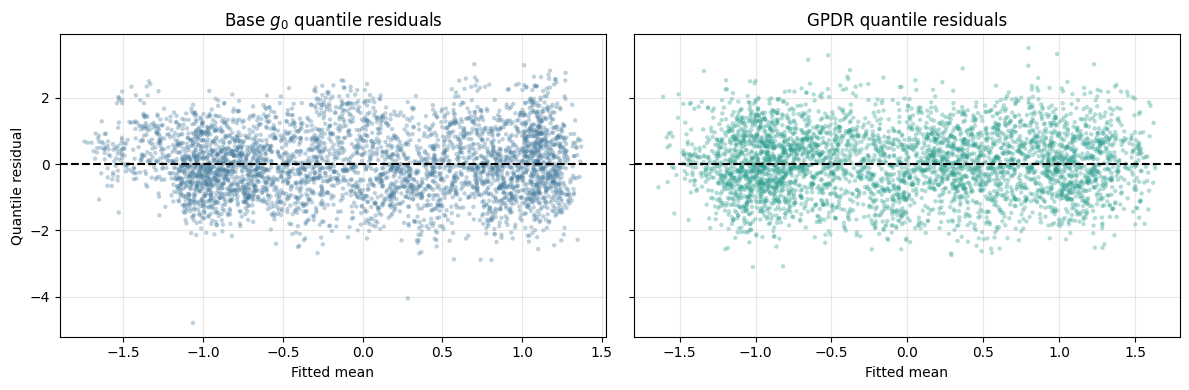

In [28]:
@torch.no_grad()
def quantile_residual_diagnostic_weather(model, x_obs, y_obs, y_min, y_max, M=1200, eps=1e-10, subset_size=300, seed=123):
    """Compute quantile residuals for GPDR and the normal base model g_0 on a reproducible subset."""
    gpdr_pit = []
    gpdr_mean = []
    base_pit = []
    base_mean = []

    x_np = x_obs.detach().cpu().numpy()
    y_np = y_obs.detach().cpu().numpy().reshape(-1)

    n_obs_total = len(y_np)
    if subset_size is not None and subset_size < n_obs_total:
        rng = np.random.default_rng(seed)
        subset_idx = np.sort(rng.choice(n_obs_total, size=subset_size, replace=False))
        x_np = x_np[subset_idx]
        y_np = y_np[subset_idx]
    else:
        subset_idx = np.arange(n_obs_total)

    for x_i, y_i in zip(x_np, y_np):
        y_grid, _, _, h_hat, _, _ = model.predict_density(x_i, y_min=y_min, y_max=y_max, M=M)

        dy = np.diff(y_grid)
        wts = np.zeros_like(y_grid)
        wts[0] = dy[0] / 2.0
        wts[-1] = dy[-1] / 2.0
        wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

        prob = h_hat * wts
        prob = prob / prob.sum()
        cdf = np.cumsum(prob)
        cdf = np.clip(cdf, 0.0, 1.0)

        pit_i = np.interp(y_i, y_grid, cdf)
        gpdr_pit.append(pit_i)
        gpdr_mean.append(float(np.sum(y_grid * prob)))

        mu_base_i = float(gam.predict(np.array(x_i).reshape(1, -1))[0])
        base_mean.append(mu_base_i)
        base_pit.append(norm.cdf(y_i, loc=mu_base_i, scale=ORIGINAL_SIGMA_NORMAL))

    gpdr_pit = np.clip(np.asarray(gpdr_pit), eps, 1.0 - eps)
    base_pit = np.clip(np.asarray(base_pit), eps, 1.0 - eps)
    gpdr_mean = np.asarray(gpdr_mean)
    base_mean = np.asarray(base_mean)

    gpdr_resid = norm.ppf(gpdr_pit)
    base_resid = norm.ppf(base_pit)

    return {
        "gpdr": {
            "pit": gpdr_pit,
            "quantile_residual": gpdr_resid,
            "fitted_mean": gpdr_mean,
            "summary": {
                "mean": float(np.mean(gpdr_resid)),
                "std": float(np.std(gpdr_resid, ddof=1)),
                "q05": float(np.quantile(gpdr_resid, 0.05)),
                "median": float(np.quantile(gpdr_resid, 0.50)),
                "q95": float(np.quantile(gpdr_resid, 0.95)),
                "n_used": int(len(gpdr_resid)),
            },
        },
        "base_g0": {
            "pit": base_pit,
            "quantile_residual": base_resid,
            "fitted_mean": base_mean,
            "summary": {
                "mean": float(np.mean(base_resid)),
                "std": float(np.std(base_resid, ddof=1)),
                "q05": float(np.quantile(base_resid, 0.05)),
                "median": float(np.quantile(base_resid, 0.50)),
                "q95": float(np.quantile(base_resid, 0.95)),
                "n_used": int(len(base_resid)),
            },
        },
        "subset_idx": subset_idx,
    }

weather_qr_diag = quantile_residual_diagnostic_weather(
    model,
    x_test,
    y_test,
    y_min=y_all.min().item(),
    y_max=y_all.max().item(),
    M=1000,
    subset_size=4000,
    seed=123,
)

print("Weather quantile residual diagnostics")
print("=" * 70)
for model_name in ["base_g0", "gpdr"]:
    payload = weather_qr_diag[model_name]
    print()
    print(model_name)
    for key, value in payload["summary"].items():
        if isinstance(value, float):
            print(f"  {key:>6s}: {value:.6f}")
        else:
            print(f"  {key:>6s}: {value}")

print() 
print(f"subset_size_used: {len(weather_qr_diag['subset_idx'])}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_specs = [
    ("base_g0", axes[0], r"Base $g_0$ quantile residuals", "#457B9D"),
    ("gpdr", axes[1], "GPDR quantile residuals", "#2A9D8F"),
]

for key, ax, title, color in plot_specs:
    fitted_mean = weather_qr_diag[key]["fitted_mean"]
    residual = weather_qr_diag[key]["quantile_residual"]
    ax.scatter(fitted_mean, residual, s=10, alpha=0.35, color=color, edgecolors="none")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Fitted mean")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Quantile residual")
plt.tight_layout()
plt.savefig("weather_quantile_residuals_vs_fitted_mean.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Benchmark Specifications

All benchmarks reuse the GPDR training and test observations. Here `x0`, `x1`, and `x2` are the transformed time, longitude, and latitude covariates. Models fit standardized temperature; RMSE and interval width are converted back to degrees Celsius. Fitting uses package defaults except for the explicit settings below.

- **GAMLSS:** Gaussian family, with `y ~ lo(~ x0 + x1 + x2)` and the same joint smooth in `sigma.formula`. `lo` is multivariate local polynomial regression, so mean and scale may depend jointly on time and space. The retained `trace.hat="approximate"` control reduces computational cost.
- **TRAM:** `BoxCox(y ~ T + S | T + S, order=6)`. Here `T` is the collection of default `bs(x0)` columns, and `S` contains all pairwise products of the default `bs(x1)` and `bs(x2)` columns: a separate temporal term plus a joint spatial term in both formula parts.
- **QRF:** all three covariates enter the forest, with default tree and split tuning settings. The current code groups every seven ordered observed dates into `week_clusters`, motivated by potential dependence between repeated station observations over nearby dates (for better performance one can use day_clusters but here we use it for save computation cost). 
- **DDPstar:** `y ~ f(x0) + f(x1, x2)`: a temporal P-spline plus a bivariate spatial P-spline. MCMC uses 1,000 burn-in and 1,000 retained draws (`nskip=1`) instead of the default 2,000/8,000 to reduce runtime.

Similar to Toy example, the retained QRF log score uses a Sturges-bin frequency polygon with Perks smoothing.


### GAMLSS Benchmark

In [74]:
# Prepare GAMLSS benchmark data from the exact same GPDR train/test split.
# The response y is kept on the standardized scale, matching the GPDR log-score calculation.

import pandas as pd
import numpy as np

x_train_np = x_train.detach().cpu().numpy() if torch.is_tensor(x_train) else np.asarray(x_train)
y_train_np = y_train.detach().cpu().numpy().reshape(-1) if torch.is_tensor(y_train) else np.asarray(y_train).reshape(-1)
x_test_np = x_test.detach().cpu().numpy() if torch.is_tensor(x_test) else np.asarray(x_test)
y_test_np = y_test.detach().cpu().numpy().reshape(-1) if torch.is_tensor(y_test) else np.asarray(y_test).reshape(-1)

benchmark_train_gamlss = pd.DataFrame({
    "x0": x_train_np[:, 0],
    "x1": x_train_np[:, 1],
    "x2": x_train_np[:, 2],
    "y": y_train_np,
})

benchmark_test_gamlss = pd.DataFrame({
    "x0": x_test_np[:, 0],
    "x1": x_test_np[:, 1],
    "x2": x_test_np[:, 2],
    "y": y_test_np,
})

print("GAMLSS train shape:", benchmark_train_gamlss.shape)
print("GAMLSS test shape: ", benchmark_test_gamlss.shape)


GAMLSS train shape: (150985, 4)
GAMLSS test shape:  (16777, 4)


In [75]:
# Load R bridge for the GAMLSS benchmark.
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [76]:
%%R -i benchmark_train_gamlss -i benchmark_test_gamlss -i y_std -o gamlss_metrics -o gamlss_density_examples

suppressPackageStartupMessages({
    library(gamlss)
    library(gamlss.dist)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_gamlss)
test_df <- as.data.frame(benchmark_test_gamlss)

# Gaussian GAMLSS with a joint time-longitude-latitude smooth for both mean and scale.
fast_lo_ctrl <- gamlss:::lo.control(
    span = 0.75,
    degree = 2,
    surface = "interpolate",
    statistics = "approximate",
    trace.hat = "approximate"
)


fit_gamlss_weather <- gamlss(
    y ~ lo(~ x0 + x1 + x2, control = fast_lo_ctrl),
    sigma.formula = ~ lo(~ x0 + x1 + x2, control = fast_lo_ctrl),
    family = NO(),
    data = train_df,
    trace = FALSE
)

prediction_start <- Sys.time()
mu_gamlss <- predict(fit_gamlss_weather, what = "mu", newdata = test_df, type = "response")
sigma_gamlss <- predict(fit_gamlss_weather, what = "sigma", newdata = test_df, type = "response")
sigma_gamlss <- pmax(sigma_gamlss, 1e-8)
y_test <- test_df$y

log_score <- sum(dNO(y_test, mu = mu_gamlss, sigma = sigma_gamlss, log = TRUE))
rmse_mean <- sqrt(mean((mu_gamlss - y_test)^2)) * as.numeric(y_std)
ci_lower <- qNO(0.025, mu = mu_gamlss, sigma = sigma_gamlss)
ci_upper <- qNO(0.975, mu = mu_gamlss, sigma = sigma_gamlss)
coverage95 <- mean((y_test >= ci_lower) & (y_test <= ci_upper))
avg_width95 <- mean(ci_upper - ci_lower) * as.numeric(y_std)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

gamlss_metrics <- data.frame(
    method = "GAMLSS Gaussian",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive density examples; use existing indices when available.
# Otherwise choose the 25%, 50%, and 75% positions in test-row order.
if (!exists("density_example_indices")) {
    density_example_indices <- as.integer(quantile(seq_along(y_test), probs = c(0.25, 0.50, 0.75)))
}
y_grid <- seq(min(y_test) - 5, max(y_test) + 5, length.out = 600)
gamlss_density_examples <- data.frame()
for (j in seq_along(density_example_indices)) {
    ii <- density_example_indices[j]
    dens <- dNO(y_grid, mu = mu_gamlss[ii], sigma = sigma_gamlss[ii])
    gamlss_density_examples <- rbind(
        gamlss_density_examples,
        data.frame(example = j, test_index = ii, y_grid = y_grid, density = dens, observed_y = y_test[ii])
    )
}

print(gamlss_metrics)



           method log_score rmse_mean coverage95 avg_width95 prediction_time
1 GAMLSS Gaussian -13608.65  4.494293  0.9527925    17.49585           0.73s


In [77]:
gpdr_reference_weather = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(estimated_log_density_vals)],
    "rmse_mean": [float(rmse_updated_orig)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(avg_length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_comparison_weather_first = pd.concat(
    [gpdr_reference_weather, gamlss_metrics],
    ignore_index=True,
)

benchmark_comparison_weather_first

,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,-10920.253706,4.035515,0.954819,15.043456,8m 49.9s
1,GAMLSS Gaussian,-13608.654814,4.494293,0.952793,17.495848,0.73s


### TRAM Benchmark


In [78]:
%%R -i benchmark_train_gamlss -i benchmark_test_gamlss -i y_std -o tram_metrics -o tram_density_examples

suppressPackageStartupMessages({
    library(tram)
    library(splines)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_gamlss)
test_df <- as.data.frame(benchmark_test_gamlss)

# Conditional transformation model benchmark.
# Build default cubic B-spline basis columns with splines::bs().  We do not set
# df manually; the basis dimension is the R default.  Time enters separately,
# while longitude and latitude enter through their tensor-product spatial basis.
make_weather_tram_basis <- function(train_df, test_df) {
    B_time_train <- bs(train_df$x0, intercept = FALSE)
    B_lon_train <- bs(train_df$x1, intercept = FALSE)
    B_lat_train <- bs(train_df$x2, intercept = FALSE)

    B_time_test <- predict(B_time_train, test_df$x0)
    B_lon_test <- predict(B_lon_train, test_df$x1)
    B_lat_test <- predict(B_lat_train, test_df$x2)

    colnames(B_time_train) <- colnames(B_time_test) <- paste0("bt", seq_len(ncol(B_time_train)))
    colnames(B_lon_train) <- colnames(B_lon_test) <- paste0("blon", seq_len(ncol(B_lon_train)))
    colnames(B_lat_train) <- colnames(B_lat_test) <- paste0("blat", seq_len(ncol(B_lat_train)))

    make_spatial_basis <- function(B_lon, B_lat) {
        vals <- list()
        k <- 1L
        for (i in seq_len(ncol(B_lon))) {
            for (j in seq_len(ncol(B_lat))) {
                vals[[paste0("bspace", k)]] <- B_lon[, i] * B_lat[, j]
                k <- k + 1L
            }
        }
        as.data.frame(vals)
    }

    train_basis <- cbind(
        data.frame(y = train_df$y),
        as.data.frame(B_time_train),
        make_spatial_basis(B_lon_train, B_lat_train)
    )
    test_basis <- cbind(
        data.frame(y = test_df$y),
        as.data.frame(B_time_test),
        make_spatial_basis(B_lon_test, B_lat_test)
    )

    list(
        train = train_basis,
        test = test_basis,
        terms = setdiff(names(train_basis), "y")
    )
}

tram_basis <- make_weather_tram_basis(train_df, test_df)
train_tram_df <- tram_basis$train
test_tram_df <- tram_basis$test
tram_terms <- tram_basis$terms
tram_formula <- as.formula(paste(
    "y ~", paste(tram_terms, collapse = " + "),
    "|", paste(tram_terms, collapse = " + ")
))

fit_tram_weather <- BoxCox(
    tram_formula,
    data = train_tram_df,
    order = 6,
)

xt <- test_tram_df[, tram_terms, drop = FALSE]
yt <- test_tram_df$y

# Log score: compute in chunks to avoid constructing a full n_test x n_test density matrix.
tram_log_score_chunks <- function(fit, xt, yt, chunk_size = 1000L, eps = 1e-12) {
    n <- length(yt)
    out <- numeric(n)
    starts <- seq.int(1L, n, by = chunk_size)
    for (s in starts) {
        e <- min(s + chunk_size - 1L, n)
        idx <- s:e
        dens_mat <- predict(fit, newdata = xt[idx, , drop = FALSE], q = yt[idx], type = "density")
        dens_diag <- diag(as.matrix(dens_mat))
        out[idx] <- log(pmax(dens_diag, eps))
    }
    sum(out)
}

prediction_start <- Sys.time()
log_score <- tram_log_score_chunks(fit_tram_weather, xt, yt)

# TRAM does not provide a closed-form conditional mean, so approximate it on a grid.
q_grid <- seq(min(train_df$y, test_df$y) - 1, max(train_df$y, test_df$y) + 1, length.out = 700)
dy <- q_grid[2] - q_grid[1]
dens_grid <- predict(fit_tram_weather, newdata = xt, q = q_grid, type = "density")
dens_grid <- as.matrix(dens_grid)
if (nrow(dens_grid) == length(yt) && ncol(dens_grid) == length(q_grid)) {
    dens_grid <- t(dens_grid)
}
if (!(nrow(dens_grid) == length(q_grid) && ncol(dens_grid) == length(yt))) {
    stop(sprintf("Unexpected TRAM density grid shape: %d x %d", nrow(dens_grid), ncol(dens_grid)))
}

mass <- pmax(colSums(dens_grid) * dy, 1e-12)
est_mean <- (colSums(dens_grid * q_grid) * dy) / mass

rmse_mean <- sqrt(mean((yt - est_mean)^2)) * as.numeric(y_std)

weighted_quantile_from_grid <- function(dens_col, prob) {
    dens_col <- ifelse(is.finite(dens_col), dens_col, 0)
    dens_col <- pmax(dens_col, 0)
    cdf <- cumsum(dens_col) * dy
    total <- max(cdf[length(cdf)], 1e-12)
    cdf <- cdf / total
    keep <- is.finite(cdf) & !duplicated(cdf)
    if (sum(keep) < 2L) {
        return(q_grid[which.max(dens_col)])
    }
    approx(cdf[keep], q_grid[keep], xout = prob, rule = 2, ties = "ordered")$y
}

lower <- apply(dens_grid, 2, weighted_quantile_from_grid, prob = 0.025)
upper <- apply(dens_grid, 2, weighted_quantile_from_grid, prob = 0.975)

coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE) * as.numeric(y_std)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

tram_metrics <- data.frame(
    method = "TRAM BoxCox",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same three representative test locations.
if (!exists("density_example_indices")) {
    density_example_indices <- as.integer(quantile(seq_along(yt), probs = c(0.25, 0.50, 0.75)))
}
y_grid <- seq(min(yt) - 5, max(yt) + 5, length.out = 600)
tram_density_examples <- data.frame()
for (j in seq_along(density_example_indices)) {
    ii <- density_example_indices[j]
    dens <- as.numeric(predict(
        fit_tram_weather,
        newdata = xt[ii, , drop = FALSE],
        q = y_grid,
        type = "density"
    ))
    tram_density_examples <- rbind(
        tram_density_examples,
        data.frame(example = j, test_index = ii, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(tram_metrics)



       method log_score rmse_mean coverage95 avg_width95 prediction_time
1 TRAM BoxCox -13392.13  4.223728  0.9508851    17.57735           7.35s


In [79]:
benchmark_comparison_weather_second = pd.concat(
    [gpdr_reference_weather, gamlss_metrics, tram_metrics],
    ignore_index=True,
)

benchmark_comparison_weather_second

,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,-10920.253706,4.035515,0.954819,15.043456,8m 49.9s
1,GAMLSS Gaussian,-13608.654814,4.494293,0.952793,17.495848,0.73s
2,TRAM BoxCox,-13392.130544,4.223728,0.950885,17.577348,7.35s


### Quantile Regression Forest Benchmark


In [ ]:
%%R -i benchmark_train_gamlss -i benchmark_test_gamlss -i y_std -o qrf_metrics -o qrf_density_examples

suppressPackageStartupMessages({
    library(grf)
    library(Matrix)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

sparse_rowsum <- function(values, rows, n) {
    out <- numeric(n)
    if (length(values) == 0) return(out)
    tmp <- rowsum(values, rows, reorder = FALSE)
    out[as.integer(rownames(tmp))] <- tmp[, 1]
    out
}

train_df <- as.data.frame(benchmark_train_gamlss)
test_df <- as.data.frame(benchmark_test_gamlss)

Xtr <- as.matrix(train_df[, c("x0", "x1", "x2")])
ytr <- train_df$y
Xte <- as.matrix(test_df[, c("x0", "x1", "x2")])
yt <- test_df$y
qrf_prediction_threads <- max(1L, parallel::detectCores() - 1L)

set.seed(2)

time_id <- as.integer(factor(
    round(train_df$x0, 10),
    levels = sort(unique(round(train_df$x0, 10)))
))

week_clusters <- ceiling(time_id / 7)

fit_qrf_weather <- quantile_forest(
    Xtr,
    ytr,
    num.trees = 2000,
    clusters = week_clusters, # temporal block cluster for repeated daily weather observations
    seed = 2,
    num.threads = 4
)

# QRF gives a weighted empirical conditional distribution rather than a smooth
# continuous density. For a density-scale log score we smooth only the evaluation
# distribution, not the QRF fit. Sturges' rule sets the number of bins; a
# frequency polygon linearly interpolates the weighted bin heights; and Perks'
# symmetric Dirichlet prior, alpha = 1/K per bin, avoids zero bin probabilities.
n_train_qrf <- length(ytr)
y_range_qrf <- range(ytr)
# Use Sturges' rule to choose the number of bins.
n_bins_qrf <- ceiling(log2(n_train_qrf) + 1)
breaks_qrf <- seq(y_range_qrf[1], y_range_qrf[2], length.out = n_bins_qrf + 1L)
centers_qrf <- (breaks_qrf[-1] + breaks_qrf[-length(breaks_qrf)]) / 2
bin_width_qrf <- diff(breaks_qrf)[1]
ytr_bin_qrf <- findInterval(ytr, breaks_qrf, all.inside = TRUE)
alpha_per_bin_qrf <- 1 / n_bins_qrf

qrf_batch_size <- 400L
n_test_qrf <- nrow(Xte)
density_at_observed <- numeric(n_test_qrf)
qrf_mean <- numeric(n_test_qrf)

prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_qrf, by = qrf_batch_size)) {
    end_idx <- min(start_idx + qrf_batch_size - 1L, n_test_qrf)
    idx <- start_idx:end_idx
    n_batch <- length(idx)

    W_batch <- get_forest_weights(
        fit_qrf_weather,
        newdata = Xte[idx, , drop = FALSE],
        num.threads = qrf_prediction_threads
    )

    qrf_mean[idx] <- as.numeric(W_batch %*% ytr)
    n_eff_batch <- 1 / Matrix::rowSums(W_batch^2)

    W_trip <- as.data.frame(summary(W_batch))
    raw_bin_mass <- sparseMatrix(
        i = W_trip$i,
        j = ytr_bin_qrf[W_trip$j],
        x = W_trip$x,
        dims = c(n_batch, n_bins_qrf)
    )
    raw_bin_mass <- as.matrix(raw_bin_mass)

    smooth_bin_mass <- sweep(
        n_eff_batch * raw_bin_mass + alpha_per_bin_qrf,
        1,
        n_eff_batch + alpha_per_bin_qrf * n_bins_qrf,
        "/"
    )
    bin_heights <- smooth_bin_mass / bin_width_qrf

    for (ii in seq_along(idx)) {
        density_at_observed[idx[ii]] <- approx(
            centers_qrf,
            bin_heights[ii, ],
            xout = yt[idx[ii]],
            rule = 2,
            ties = "ordered"
        )$y
    }
}

log_score <- sum(log(pmax(density_at_observed, .Machine$double.xmin)))
rmse_mean <- sqrt(mean((yt - qrf_mean)^2)) * as.numeric(y_std)

# Keep interval estimates from the QRF quantile predictor.
qrf_interval_probs <- c(0.025, 0.975)
qrf_interval <- predict(
    fit_qrf_weather,
    Xte,
    quantiles = qrf_interval_probs,
    num.threads = qrf_prediction_threads
)$predictions
qrf_interval <- as.matrix(qrf_interval)
lower <- qrf_interval[, 1]
upper <- qrf_interval[, 2]
coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE) * as.numeric(y_std)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

qrf_metrics <- data.frame(
    method = "Quantile RF",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

cat(sprintf("QRF Sturges frequency-polygon bins: %d\n", n_bins_qrf))
cat(sprintf("QRF Perks smoothing alpha per bin: %.6f\n", alpha_per_bin_qrf))

# Predictive densities at the same three representative test locations, using
# the same frequency-polygon density definition as the log-score calculation.
if (!exists("density_example_indices")) {
    density_example_indices <- as.integer(quantile(seq_along(yt), probs = c(0.25, 0.50, 0.75)))
}
y_grid <- seq(min(yt) - 5, max(yt) + 5, length.out = 600)
qrf_density_examples <- data.frame()

for (j in seq_along(density_example_indices)) {
    ii <- density_example_indices[j]
    w_sparse <- get_forest_weights(
        fit_qrf_weather,
        newdata = Xte[ii, , drop = FALSE],
        num.threads = qrf_prediction_threads
    )
    w_trip <- as.data.frame(summary(w_sparse))
    raw_bin_mass <- sparse_rowsum(w_trip$x, ytr_bin_qrf[w_trip$j], n_bins_qrf)
    n_eff_row <- 1 / sum(w_trip$x^2)

    smooth_bin_mass <- (n_eff_row * raw_bin_mass + alpha_per_bin_qrf) /
        (n_eff_row + alpha_per_bin_qrf * n_bins_qrf)
    bin_heights <- smooth_bin_mass / bin_width_qrf

    dens <- approx(
        centers_qrf,
        bin_heights,
        xout = y_grid,
        rule = 2,
        ties = "ordered"
    )$y

    qrf_density_examples <- rbind(
        qrf_density_examples,
        data.frame(example = j, test_index = ii, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(qrf_metrics)

QRF Sturges frequency-polygon bins: 19
QRF Perks smoothing alpha per bin: 0.052632
       method log_score rmse_mean coverage95 avg_width95 prediction_time
1 Quantile RF -19398.55   6.61159  0.9726411    28.44638          6m 12s


In [81]:
benchmark_comparison_weather_third = pd.concat(
    [benchmark_comparison_weather_second, qrf_metrics],
    ignore_index=True,
)

benchmark_comparison_weather_third


,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,-10920.253706,4.035515,0.954819,15.043456,8m 49.9s
1,GAMLSS Gaussian,-13608.654814,4.494293,0.952793,17.495848,0.73s
2,TRAM BoxCox,-13392.130544,4.223728,0.950885,17.577348,7.35s
3,Quantile RF,-19398.551766,6.611590,0.972641,28.446385,6m 12s


### DDPstar Benchmark


In [82]:
%%R -i benchmark_train_gamlss -i benchmark_test_gamlss -i y_std -o ddpstar_metrics -o ddpstar_density_examples

suppressPackageStartupMessages({
    library(DDPstar)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_gamlss)
test_df <- as.data.frame(benchmark_test_gamlss)

set.seed(2)
fit_ddpstar_weather <- DDPstar(
    y ~ f(x0, nseg = 5, bdeg = 3, pord = 2, atau = 1, btau = 0.005) +
        f(x1, x2, nseg = c(5, 5), bdeg = 3, pord = 2, atau = 1, btau = 0.005,
          prior.2D = "anisotropic"),
    data = train_df,
    prior = list(a = 2, b = 0.5, aalpha = 2, balpha = 2, L = 10),
    mcmc = list(nburn = 1000, nsave = 1000, nskip = 1),
    standardise = TRUE,
    verbose = FALSE
)

xt <- test_df[, c("x0", "x1", "x2"), drop = FALSE]
yt <- test_df$y
n_test_ddp <- length(yt)

ddpstar_mean <- numeric(n_test_ddp)
ddpstar_lower <- numeric(n_test_ddp)
ddpstar_upper <- numeric(n_test_ddp)
ddpstar_density_at_observed <- numeric(n_test_ddp)

# Wider grid for fallback interval calculation if DDPstar's quantfun root finder fails.
ddp_y_grid <- seq(min(c(train_df$y, test_df$y)) - 1, max(c(train_df$y, test_df$y)) + 1, length.out = 700)
ddp_dy <- ddp_y_grid[2] - ddp_y_grid[1]

ddpstar_density_diag <- function(fit, newdata_batch, y_batch, eps = 1e-12) {
    pred_den <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = y_batch,
        parallel = "no"
    )$denfun
    d <- dim(pred_den)
    if (length(d) != 3L) {
        stop("Unexpected DDPstar denfun output: expected a 3D array.")
    }
    out <- numeric(length(y_batch))
    for (j in seq_along(y_batch)) {
        out[j] <- mean(pred_den[j, j, ], na.rm = TRUE)
    }
    pmax(out, eps)
}

ddpstar_grid_intervals <- function(fit, newdata_batch, probs = c(0.025, 0.975)) {
    pred_grid <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = ddp_y_grid,
        parallel = "no"
    )$denfun
    den_mean <- apply(pred_grid, c(1, 2), mean, na.rm = TRUE)
    if (is.null(dim(den_mean))) {
        den_mean <- matrix(den_mean, nrow = length(ddp_y_grid), ncol = 1L)
    }
    if (nrow(den_mean) != length(ddp_y_grid)) {
        den_mean <- t(den_mean)
    }
    lower <- numeric(ncol(den_mean))
    upper <- numeric(ncol(den_mean))
    for (j in seq_len(ncol(den_mean))) {
        dens <- pmax(den_mean[, j], 0)
        mass <- sum(dens) * ddp_dy
        if (!is.finite(mass) || mass <= 0) {
            lower[j] <- NA_real_
            upper[j] <- NA_real_
        } else {
            cdf <- cumsum(dens) * ddp_dy / mass
            lower[j] <- approx(cdf, ddp_y_grid, xout = probs[1], ties = "ordered", rule = 2)$y
            upper[j] <- approx(cdf, ddp_y_grid, xout = probs[2], ties = "ordered", rule = 2)$y
        }
    }
    list(lower = lower, upper = upper)
}

# Batch posterior predictive arrays to limit memory use.
ddpstar_batch_size <- 100L
prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_ddp, by = ddpstar_batch_size)) {
    end_idx <- min(start_idx + ddpstar_batch_size - 1L, n_test_ddp)
    idx <- start_idx:end_idx
    new_batch <- xt[idx, , drop = FALSE]
    y_batch <- yt[idx]

    pred_reg <- predict(
        fit_ddpstar_weather,
        newdata = new_batch,
        what = "regfun",
        parallel = "no"
    )$regfun
    pred_reg <- as.matrix(pred_reg)
    if (nrow(pred_reg) != length(idx) && ncol(pred_reg) == length(idx)) {
        pred_reg <- t(pred_reg)
    }
    ddpstar_mean[idx] <- rowMeans(pred_reg, na.rm = TRUE)

    quant_ok <- TRUE
    pred_q <- tryCatch(
        predict(
            fit_ddpstar_weather,
            newdata = new_batch,
            what = "quantfun",
            quant.probs = c(0.025, 0.975),
            parallel = "no"
        )$quantfun,
        error = function(e) {
            quant_ok <<- FALSE
            NULL
        }
    )
    if (quant_ok) {
        ddpstar_lower[idx] <- apply(pred_q[, , 1, drop = FALSE], 1, median, na.rm = TRUE)
        ddpstar_upper[idx] <- apply(pred_q[, , 2, drop = FALSE], 1, median, na.rm = TRUE)
    } else {
        grid_q <- ddpstar_grid_intervals(fit_ddpstar_weather, new_batch)
        ddpstar_lower[idx] <- grid_q$lower
        ddpstar_upper[idx] <- grid_q$upper
    }

    ddpstar_density_at_observed[idx] <- ddpstar_density_diag(
        fit_ddpstar_weather,
        new_batch,
        y_batch
    )

    if (start_idx == 1L || end_idx == n_test_ddp || start_idx %% 1000L == 1L) {
        cat(sprintf("DDPstar prediction progress: %d / %d\n", end_idx, n_test_ddp))
    }
}

log_score <- sum(log(pmax(ddpstar_density_at_observed, 1e-12)))
rmse_mean <- sqrt(mean((yt - ddpstar_mean)^2)) * as.numeric(y_std)
coverage95 <- mean(yt >= ddpstar_lower & yt <= ddpstar_upper, na.rm = TRUE)
avg_width95 <- mean(ddpstar_upper - ddpstar_lower, na.rm = TRUE) * as.numeric(y_std)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

ddpstar_metrics <- data.frame(
    method = "DDPstar",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same three representative test locations.
if (!exists("density_example_indices")) {
    density_example_indices <- as.integer(quantile(seq_along(yt), probs = c(0.25, 0.50, 0.75)))
}
y_grid <- seq(min(yt) - 5, max(yt) + 5, length.out = 600)
ddpstar_density_examples <- data.frame()
for (j in seq_along(density_example_indices)) {
    ii <- density_example_indices[j]
    pred_grid <- predict(
        fit_ddpstar_weather,
        newdata = xt[ii, , drop = FALSE],
        what = "denfun",
        den.grid = y_grid,
        parallel = "no"
    )$denfun
    dens <- apply(pred_grid[, 1, , drop = FALSE], 1, mean, na.rm = TRUE)
    ddpstar_density_examples <- rbind(
        ddpstar_density_examples,
        data.frame(example = j, test_index = ii, y_grid = y_grid, density = dens, observed_y = yt[ii])
    )
}

print(ddpstar_metrics)



DDPstar prediction progress: 100 / 16777
DDPstar prediction progress: 1100 / 16777
DDPstar prediction progress: 2100 / 16777
DDPstar prediction progress: 3100 / 16777
DDPstar prediction progress: 4100 / 16777
DDPstar prediction progress: 5100 / 16777
DDPstar prediction progress: 6100 / 16777
DDPstar prediction progress: 7100 / 16777
DDPstar prediction progress: 8100 / 16777
DDPstar prediction progress: 9100 / 16777
DDPstar prediction progress: 10100 / 16777
DDPstar prediction progress: 11100 / 16777
DDPstar prediction progress: 12100 / 16777
DDPstar prediction progress: 13100 / 16777
DDPstar prediction progress: 14100 / 16777
DDPstar prediction progress: 15100 / 16777
DDPstar prediction progress: 16100 / 16777
DDPstar prediction progress: 16777 / 16777
   method log_score rmse_mean coverage95 avg_width95 prediction_time
1 DDPstar -11049.91  4.091331  0.9520176    15.01241       8h 32m 0s


### Benchmark Metric Comparison: All Methods Including DDPstar



In [83]:
# Compare GPDR and all benchmark distributional regression models, including DDPstar when available.
# GPDR metrics are taken from the GPDR evaluation cells above:
# - estimated_log_density_vals: test log score for \hat{h}
# - rmse_updated_orig: RMSE of GPDR fitted mean on the original temperature scale
# - coverage_updated: 95% CI coverage for GPDR
# - avg_length_updated: average 95% CI width for GPDR on the original temperature scale

if "gpdr_prediction_time" not in globals():
    raise RuntimeError("Run the GPDR log-score and metric cells first so GPDR prediction_time is available.")

gpdr_reference_weather = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(estimated_log_density_vals)],
    "rmse_mean": [float(rmse_updated_orig)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(avg_length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_frames = [gpdr_reference_weather, gamlss_metrics, tram_metrics, qrf_metrics]
if "ddpstar_metrics" in globals():
    benchmark_frames.append(ddpstar_metrics)

for frame in benchmark_frames:
    if "prediction_time" not in frame.columns:
        raise RuntimeError("A benchmark metric table is missing prediction_time. Re-run that benchmark cell.")

benchmark_comparison_weather_all = pd.concat(
    benchmark_frames,
    ignore_index=True,
)[["method", "log_score", "rmse_mean", "coverage95", "avg_width95", "prediction_time"]]

benchmark_comparison_weather_all



,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,-10920.253706,4.035515,0.954819,15.043456,8m 49.9s
1,GAMLSS Gaussian,-13608.654814,4.494293,0.952793,17.495848,0.73s
2,TRAM BoxCox,-13392.130544,4.223728,0.950885,17.577348,7.35s
3,Quantile RF,-19398.551766,6.611590,0.972641,28.446385,6m 12s
4,DDPstar,-11049.913184,4.091331,0.952018,15.012406,8h 32m 0s
